# CAS KAGGLE: `Detection of Pistachio Types By Classifier Models`


## INTRODUCCIÓ

## BASE DE DADES

En el nostre Cas Kaggle hem triat una base de dades de pistatxos, que a partir atributs extrets d'imatges processades té l'objectiu de predir de quin tipus de pistatxo es tracta: `Kirmizi` o  bé `Siit`.

https://www.kaggle.com/datasets/amirhosseinmirzaie/pistachio-types-detection/data

Importem les llibreries que necessitarem.

In [252]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from IPython.display import Image
from tqdm import tqdm
from itertools import combinations

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

In [253]:
df = pd.read_csv("./archive/pistachio.csv")


In [254]:
df.describe(include="all")

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
count,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1718
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kirmizi_Pistachio
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,998
mean,79871.952852,1421.797588,446.206444,238.193128,0.840347,317.790000,0.940103,84947.671129,0.716055,1.899342,0.570831,0.712841,0.005704,0.003017,0.510097,0.955185,NaN
std,12968.217051,373.408835,31.885328,30.426445,0.049026,26.571699,0.050006,13081.742551,0.052534,0.241253,0.211514,0.044230,0.000810,0.000334,0.063391,0.051735,NaN
min,29808.000000,858.363000,321.425500,133.509600,0.504900,194.814600,0.588000,37935.000000,0.427200,1.158500,0.062800,0.476000,0.004000,0.002400,0.226600,0.620400,NaN
25%,71898.500000,1169.633225,426.554100,217.875475,0.817500,302.562375,0.920250,76357.750000,0.688100,1.736325,0.372325,0.682000,0.005200,0.002800,0.465125,0.944200,NaN
50%,79795.000000,1260.785500,448.453150,235.888750,0.850250,318.744650,0.953800,84973.000000,0.726100,1.899550,0.643850,0.709750,0.005600,0.003000,0.503750,0.972800,NaN
75%,88980.000000,1599.479000,467.515200,257.433625,0.875375,336.590000,0.976300,93660.750000,0.753600,2.068575,0.744450,0.741600,0.006100,0.003200,0.549975,0.986800,NaN


La nostra base de dades té els següents atributs on `int64` és un nombre enter, `float64` és un nombre decimal i `object` una cadena de text.

In [255]:
df.dtypes

AREA               int64
PERIMETER        float64
MAJOR_AXIS       float64
MINOR_AXIS       float64
ECCENTRICITY     float64
EQDIASQ          float64
SOLIDITY         float64
CONVEX_AREA        int64
EXTENT           float64
ASPECT_RATIO     float64
ROUNDNESS        float64
COMPACTNESS      float64
SHAPEFACTOR_1    float64
SHAPEFACTOR_2    float64
SHAPEFACTOR_3    float64
SHAPEFACTOR_4    float64
Class             object
dtype: object

En la següent fotografía podem observar millor a que correspon cada atribut:

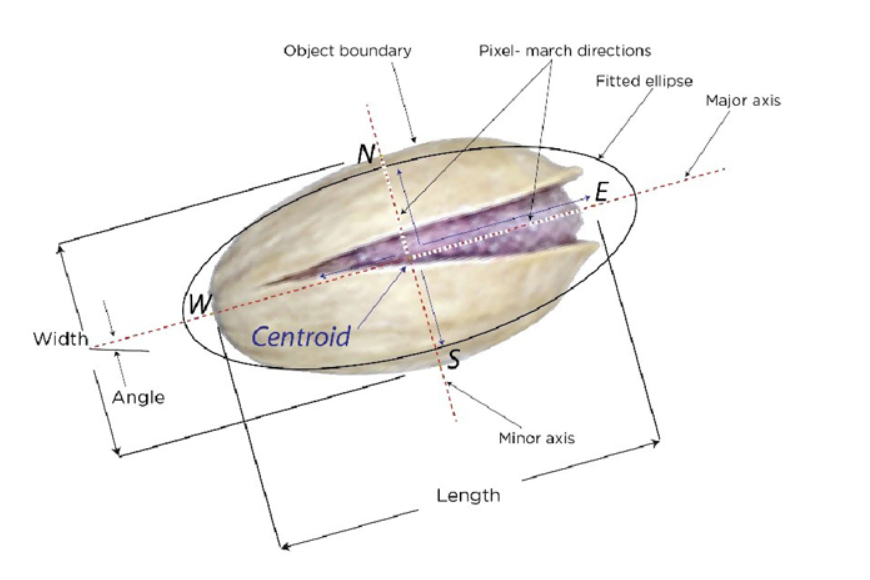

In [256]:
Image(filename='Imatges/imatge_atributs_pistatxo.png')


- `AREA`: nombre enter, l'àrea de pistatxo detectada a l'imatge.
- `PERIMETER`: nombre decimal, perímetre del pistatxo (frontera de l'imatge detectada).
- `MAJOR_AXIS`: nombre decimal, llargada de l'eix major de l'el·lipse que millor s'adapta a l'imatge del pistatxo.
- `MINOR_AXIS`: nombre decimal, llargada de l'eix menor de l'el·lipse que millor s'adapta a l'imatge del pistatxo.
- `ECCENTRICITY`: nombre decimal, excentricitat de l'el·lipse (que tan allargada està) de la regió del pistatxo ($e=\sqrt{1-\frac{b^2}{a^2}}$).
- `EQDIASQ`: nombre decimal, diàmetre del cercle que tindria la mateixa àrea que l'el·lipse del pistatxo.
- `SOLIDITY`: nombre decimal, proporció entre l'àrea real i l'àrea del polígon convex que millor envolta el pistatxo $\frac{\text{ÀREA PISTATXO}}{\text{ÀREA POLÍGON CONVEX}}$.
- `CONVEX_AREA`: nombre enter, àrea del polígon convex que millor envolta el pistatxo. 
- `EXTENT`: nombre decimal, proporció entre l'àrea real i l'àrea del rectangle que millor envolta el pistatxo ($\frac{\text{ÀREA PISTATXO}}{\text{ÀREA RECTANGLE}}$).
- `ASPECT_RATIO`: nombre decimal, proporció entre eix major i menor ($\frac{\text{EIX MAJOR}}{\text{EIX MENOR}}$).
- `ROUNDNESS`: nombre decimal, mesura que tant s'assembla la regió del pistatxo a un cercle.
- `COMPACTNESS`: nombre decimal, mesura que tant concentrada està la forma de l'objecte comparant mida i elongació.
- `SHAPEFACTOR_1`, `SHAPEFACTOR_2`, `SHAPEFACTOR_3`, `SHAPEFACTOR_4`: nombres decimals, són atributs extrets de l'àrea i perímetre de la regió del pistatxo, no hi ha molta més informació de sobre que es tracten. 

El Target és l'atribut categòric `Class`, que pot prendre dos valors `Kirmizi_Pistachio` o `Siit_Pistachio` depenent quin tipus de pistatxo sigui.

In [257]:
df['Class'].value_counts()

Class
Kirmizi_Pistachio    998
Siit_Pistachio       720
Name: count, dtype: int64

In [258]:
df.isna().sum()

AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
Class            0
dtype: int64

Veiem que no ens falten dades, totes les variables tenen tots els valors en cada mostra.

Per a poder analitzar les dades hem decidit agrupar totes les funcions que anem a utilitzar en una sola classe.

In [259]:
class DatasetAnalyzer:
    """
    Classe per analitzar i processar les dades d'un dataset
    """

    def __init__(self, df, target="Class"):
        """
        Inicialitza el DatasetAnalyzer.

        df: DataFrame d'entrada
        target: Nom de la variable objectiu
        """
        self.df = df.copy()
        self.target = target
        self.encoder = None
        self.labels = None

    def get_numeric_columns(self):
        """
        Retorna una llista amb totes les columnes numèriques del DataFrame.
        """
        return self.df.select_dtypes(include='number').columns.tolist()

    def get_class_values(self):
        """
        Retorna els valors únics de la variable objectiu (classes).
        """
        return self.df[self.target].unique()

    def encode_target(self):
        """
        Converteix la variable objectiu a valors numèrics amb LabelEncoder.
        Retorna un diccionari que mapeja ID: nom original de la classe.
        """
        if not np.issubdtype(self.df[self.target].dtype, np.number):
            self.encoder = LabelEncoder()
            self.df[self.target] = self.encoder.fit_transform(self.df[self.target])
            self.labels = {
                int(k): v for k, v in
                zip(self.encoder.transform(self.encoder.classes_), self.encoder.classes_)
            }
        else:
            self.labels = None
        return self.labels
    
    def decode_target(self):
        """
        Torna la variable objectiu a les seves classes originals (no codificades).
        Només funciona si prèviament s'ha fet encode_target().
        """
        if self.encoder is None:
            return None
        
        decoded = self.encoder.inverse_transform(self.df[self.target])
        self.df[self.target] = decoded
        return self.df[self.target].unique()

    def plot_histograms(self):
        """
        Genera un histograma per a cada variable del DataFrame.
        """
        cols = self.df.columns
        n_cols = len(cols)

        total_plots = n_cols
        rows = math.ceil(total_plots / 3)

        plt.figure(figsize=(18, 4 * rows))
        colors = sns.color_palette("Set2", n_cols)

        for i, col in enumerate(cols, 1):
            plt.subplot(rows, 3, i)
            plt.hist(self.df[col], bins=30, edgecolor='black', color=colors[i-1])
            plt.title(col)
            plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_histograms_by_class(self):
        """
        Mostra histogrames apilats per classe per a cada variable numèrica.
        """
        self.encode_target()
        numeric_cols = self.get_numeric_columns()
        n_numeric = len(numeric_cols)

        rows = math.ceil(n_numeric / 3)
        plt.figure(figsize=(18, 5 * rows))

        for i, col in enumerate(numeric_cols, 1):
            plt.subplot(rows, 3, i)
            sns.histplot(
                data=self.df, x=col, hue=self.target,
                multiple='stack', palette='Set1',
                edgecolor='black', bins=30
            )
            plt.title(col)
            plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_separate_histograms_by_class(self):
        """
        Crea dos histogrames separats per cada variable numèrica:
        un per cada classe, amb l'eix X igualat per comparar formes.
        """
        self.encode_target()
        numeric_cols = self.get_numeric_columns()
        classes = self.get_class_values()
        n_numeric = len(numeric_cols)

        rows = math.ceil(n_numeric / 2)
        fig, axes = plt.subplots(rows, 4, figsize=(24, 5 * rows))
        axes = axes.flatten()

        for i, col in enumerate(numeric_cols):
            range_val = self.df[col].max() - self.df[col].min()
            offset = range_val * 0.05
            min_val = self.df[col].min() - offset
            max_val = self.df[col].max() + offset

            for j, cl in enumerate(classes):
                ax = axes[i*2 + j]
                data = self.df[self.df[self.target] == cl][col]

                ax.hist(data, bins=20, edgecolor='black',
                        alpha=0.7, color=f'C{j}')
                ax.set_title(f'{col} - Class: {cl}')
                ax.set_xlabel(col)
                ax.set_ylabel('Count')
                ax.set_xlim(min_val, max_val)
                ax.grid(alpha=0.3)

        for k in range(len(numeric_cols)*2, len(axes)):
            axes[k].axis('off')

        plt.tight_layout()
        plt.show()
        
    def plot_boxplots(self):
        """
        Mostra boxplots de cada variable numèrica dividits per classes.
        """
        self.decode_target()
        numeric_cols = self.get_numeric_columns()
        plt.figure(figsize=(18, 5 * math.ceil(len(numeric_cols) / 3)))

        for i, col in enumerate(numeric_cols, 1):
            plt.subplot(math.ceil(len(numeric_cols) / 3), 3, i)
            sns.boxplot(data=self.df, x=self.target, y=col, hue=self.target, palette="Set2", dodge=False)
            plt.title(f'Boxplot de {col} segons {self.target}')
            plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_correlation_matrix(self):
        """
        Genera un mapa de calor de la matriu de correlació de variables numèriques.
        """
        plt.figure(figsize=(12, 10))
        corr_matrix = self.df.corr(numeric_only=True)
        sns.heatmap(corr_matrix, annot=True)
        plt.tight_layout()
        plt.show()

    def plot_corr_with_target(self):
        """
        Calcula i mostra la correlació de cada variable numèrica amb la variable objectiu.
        """
        self.encode_target()
        corr_with_target = self.df.corr(numeric_only=True)[self.target].abs().drop(self.target)
        corr_with_target = corr_with_target.sort_values(ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(
            x=corr_with_target.index,
            y=corr_with_target.values,
            palette='viridis'
        )
        plt.title(f'Correlació amb {self.target}')
        plt.xlabel('Variables')
        plt.ylabel('Correlació')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    def drop_highly_correlated(self, threshold=0.8):
        """
        Elimina variables molt correlacionades entre elles.
        Manté la variable més útil (la que correlaciona més amb la target).
        Retorna la llista de variables eliminades.
        """
        self.encode_target()
        corr_matrix = self.df.corr(numeric_only=True).abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        to_drop = set()

        for col in upper_tri.columns:
            for row in upper_tri.index:
                corr_value = upper_tri.loc[row, col]
                if corr_value > threshold:
                    corr_row_target = abs(self.df[row].corr(self.df[self.target]))
                    corr_col_target = abs(self.df[col].corr(self.df[self.target]))

                    if corr_row_target > corr_col_target:
                        to_drop.add(col)
                    else:
                      to_drop.add(row)

        self.df = self.df.drop(columns=list(to_drop))
        return list(to_drop)
    
    def estandaritzar_variables(self):
        """
        Aplica StandardScaler a totes les variables numèriques excepte la variable objectiu.
        Modifica el DataFrame intern self.df amb les variables estandaritzades.
        """
        numeric_cols = self.get_numeric_columns()
        
        # Excloure la columna target si és numèrica
        if self.target in numeric_cols:
            numeric_cols.remove(self.target)
        
        self.df[numeric_cols] = StandardScaler().fit_transform(self.df[numeric_cols])

        return self.df
    
    def update_dataset(self, features: list = None):
        """
        Actualitza el dataset intern per contenir només les features indicades i la variable objectiu.

        - features: llista de columnes a mantenir (excloent la variable objectiu)
        Si no es proporciona, retorna el dataset original sense canvis.

        Retorna:
        - dataframe actualitzat amb només les features indicades i la columna target.
        """

        if features is not None:
            missing = [c for c in features if c not in self.df.columns]
            if missing:
                raise ValueError(f"Features inexistents: {missing}")
            
            # Conservar només les features indicades + la variable objectiu
            return self.df[features + [self.target]].copy()

        return self.df.copy()



In [260]:
analyzer  = DatasetAnalyzer(df, target="Class")

In [261]:
numeric_cols = analyzer.get_numeric_columns()
print("Columnes numèriques:", numeric_cols)

Columnes numèriques: ['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY', 'EQDIASQ', 'SOLIDITY', 'CONVEX_AREA', 'EXTENT', 'ASPECT_RATIO', 'ROUNDNESS', 'COMPACTNESS', 'SHAPEFACTOR_1', 'SHAPEFACTOR_2', 'SHAPEFACTOR_3', 'SHAPEFACTOR_4']


In [262]:
class_values = analyzer.get_class_values()
print("Classes:", class_values)

Classes: ['Kirmizi_Pistachio' 'Siit_Pistachio']


Ara estudiem la distribució de les dades amb els següents gràfics.

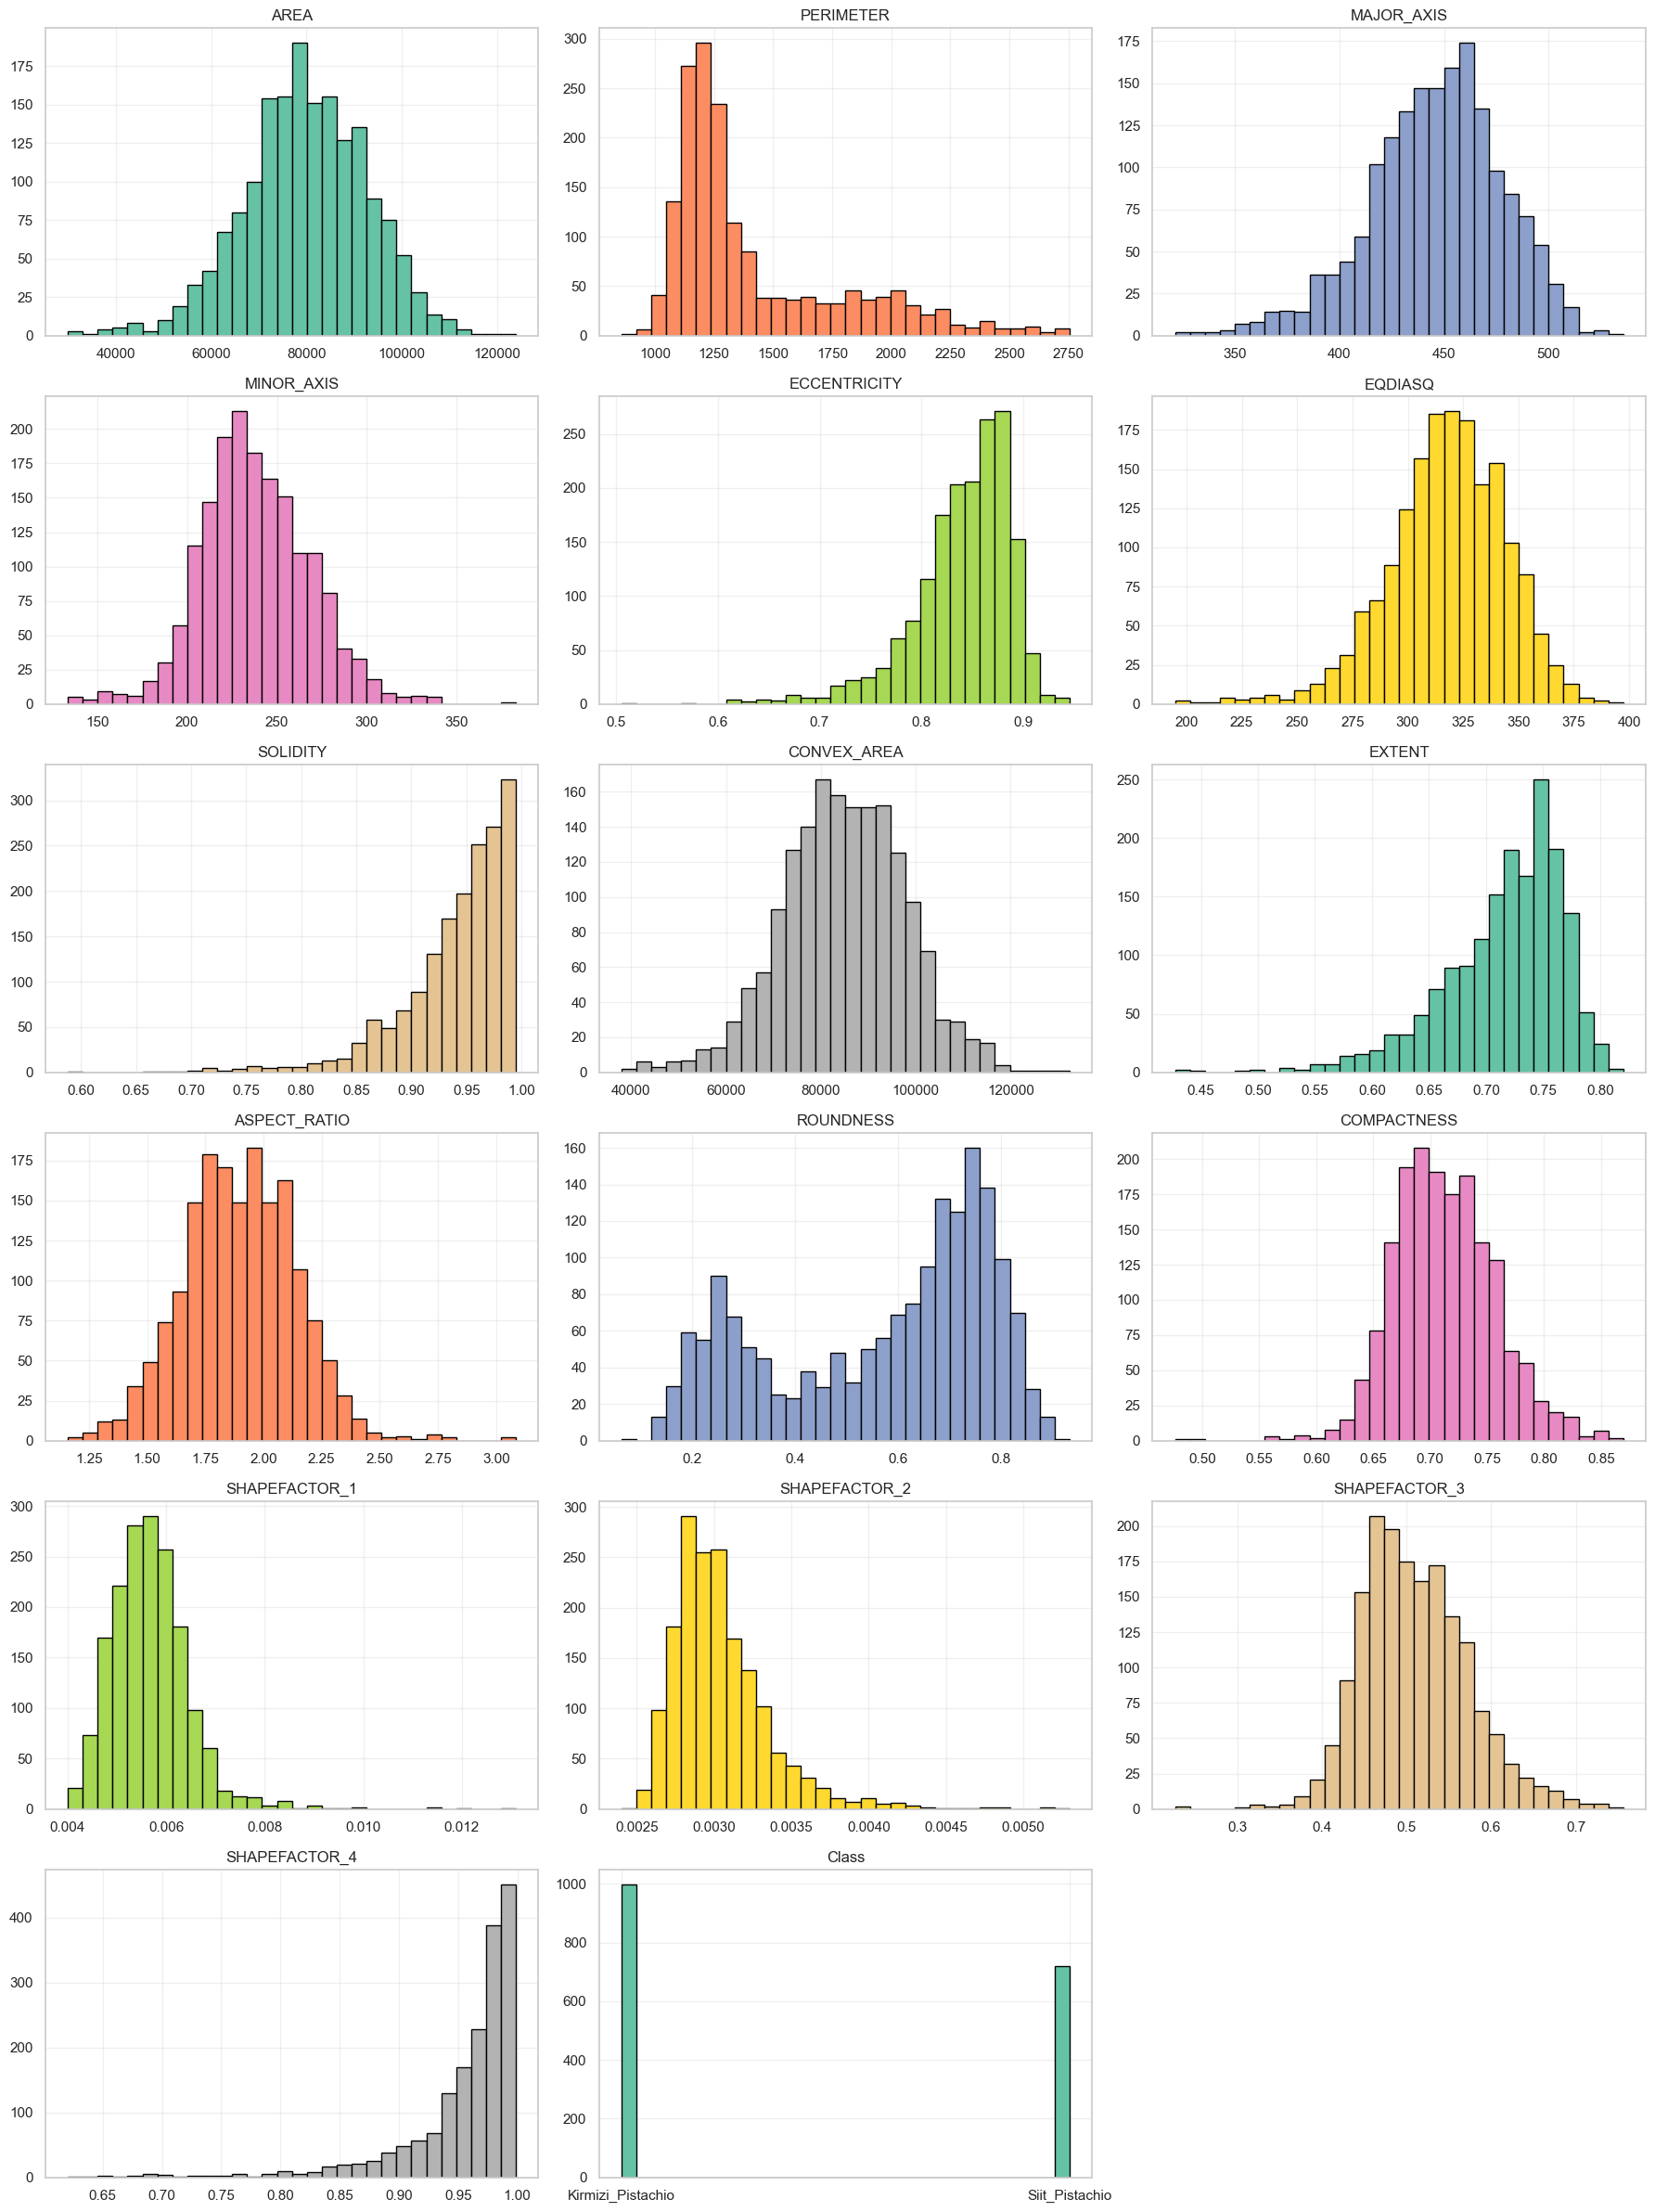

In [263]:
analyzer.plot_histograms()

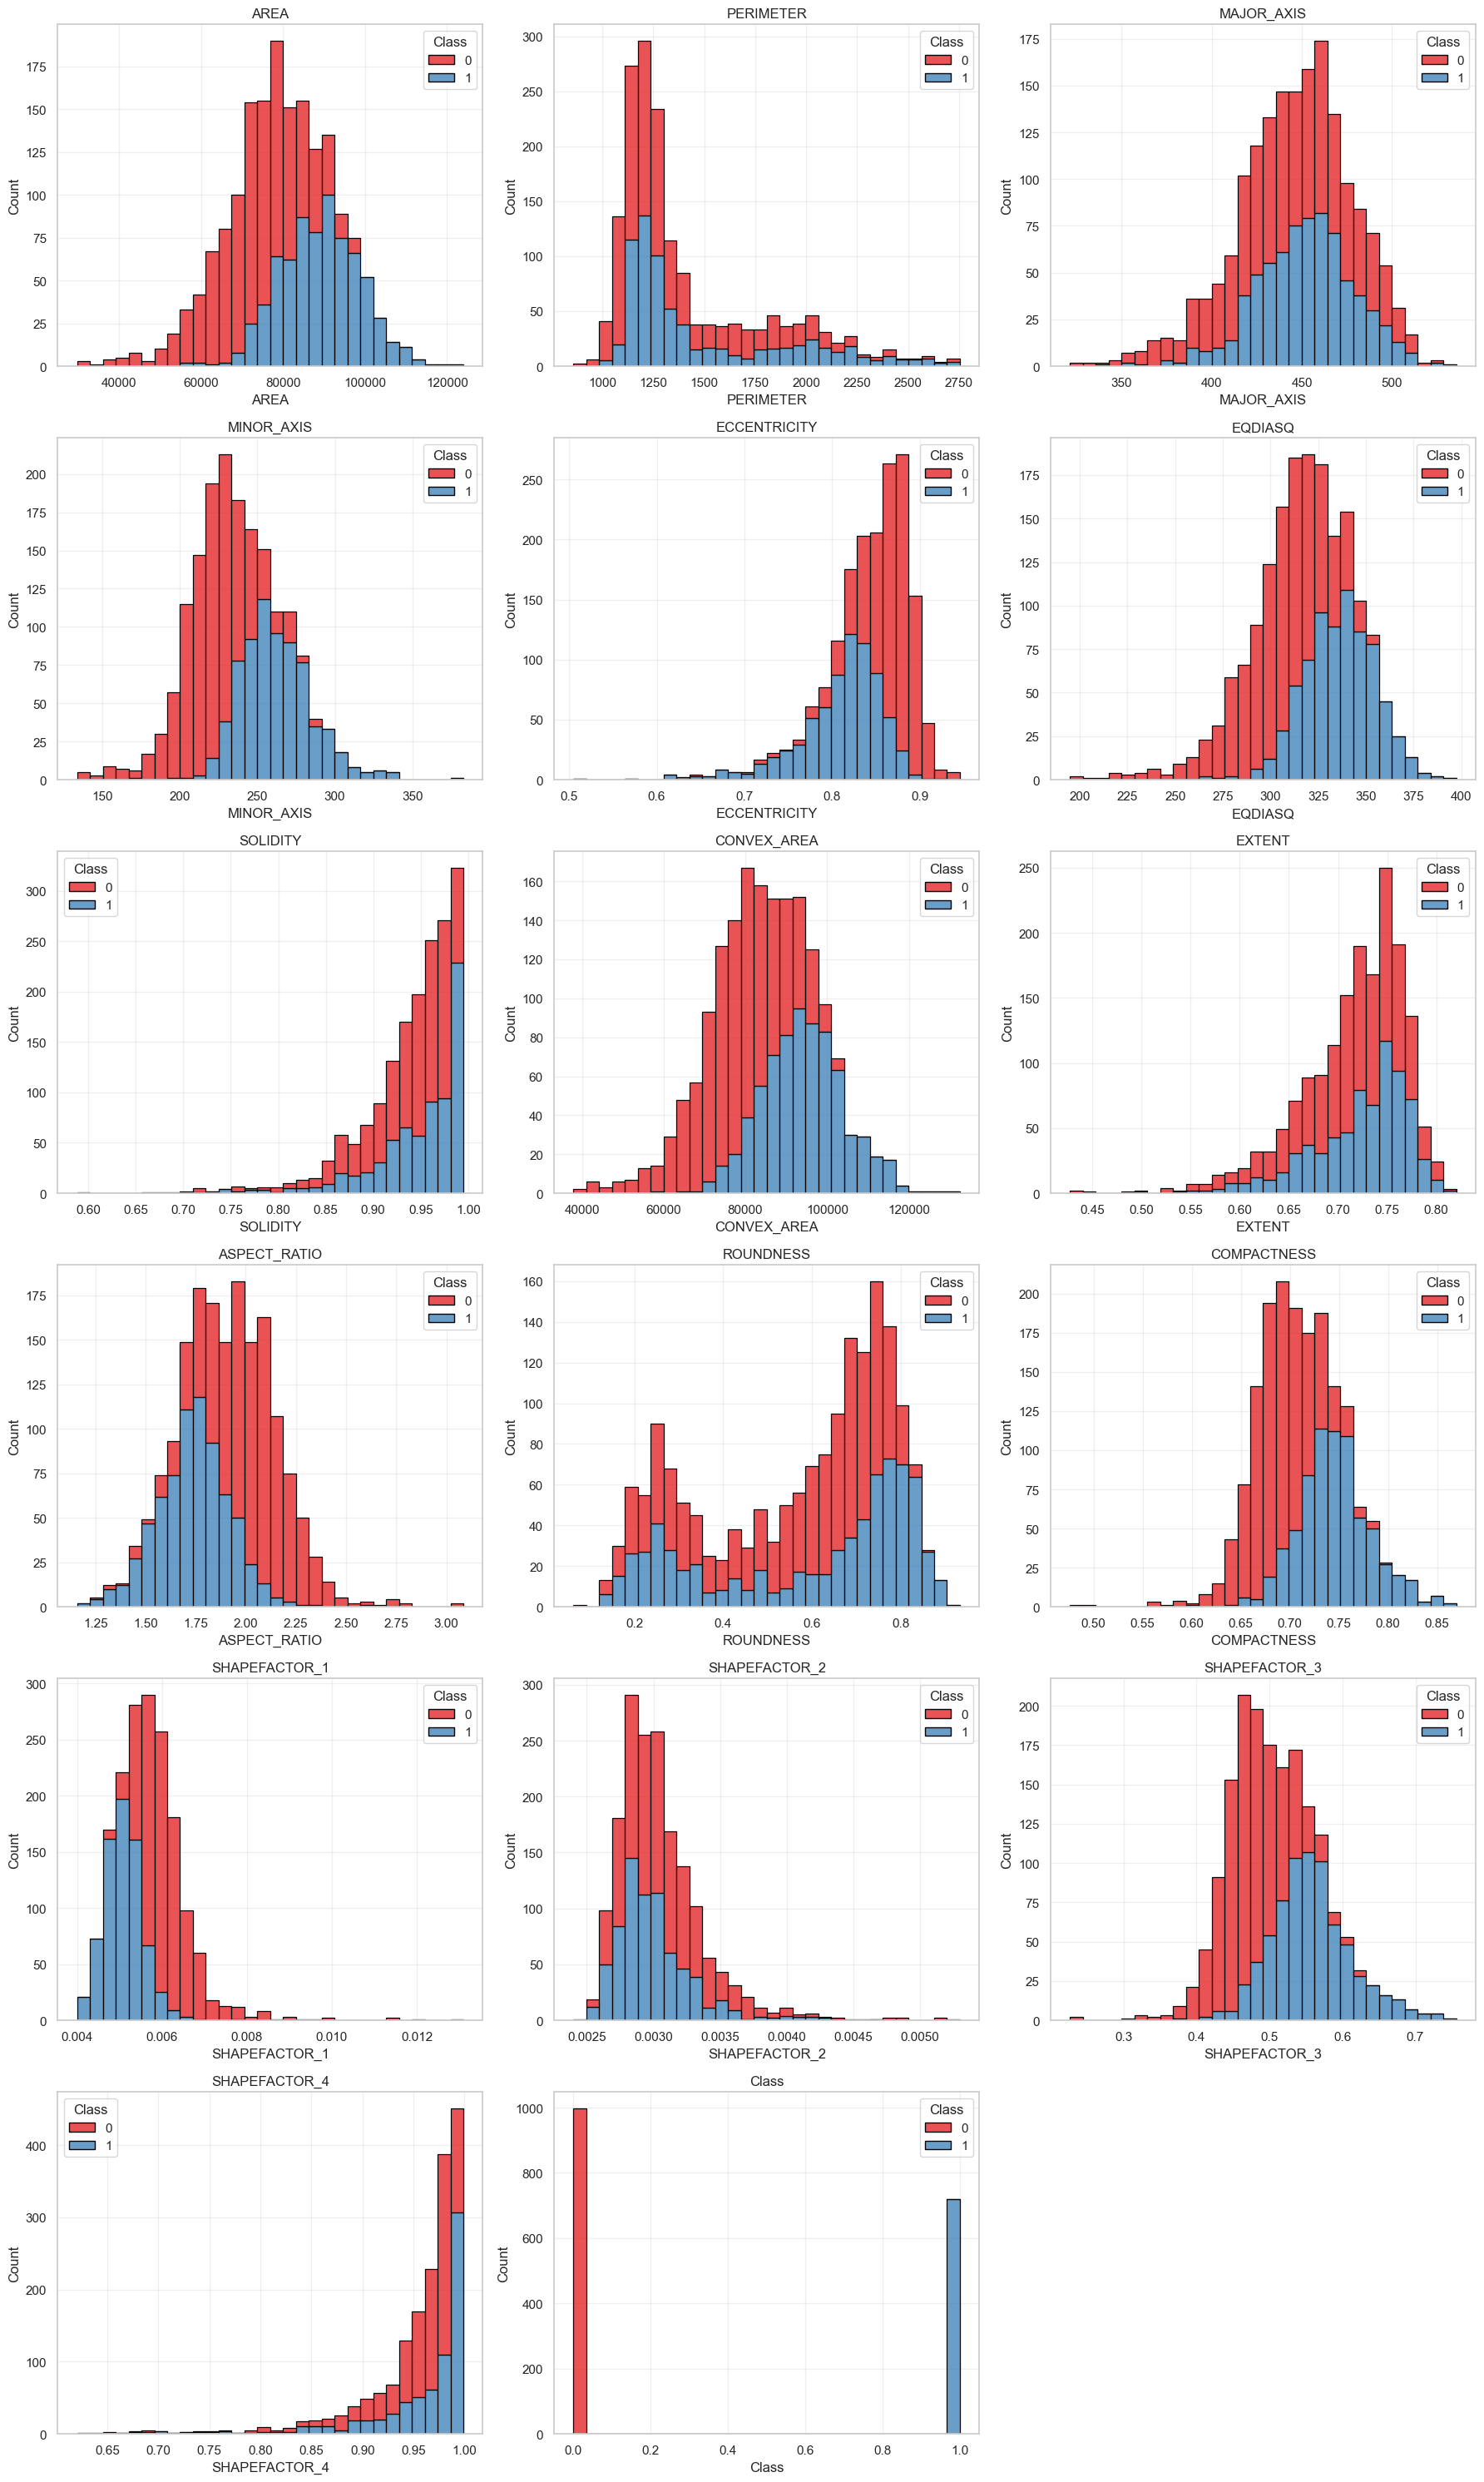

In [264]:
analyzer.plot_histograms_by_class()

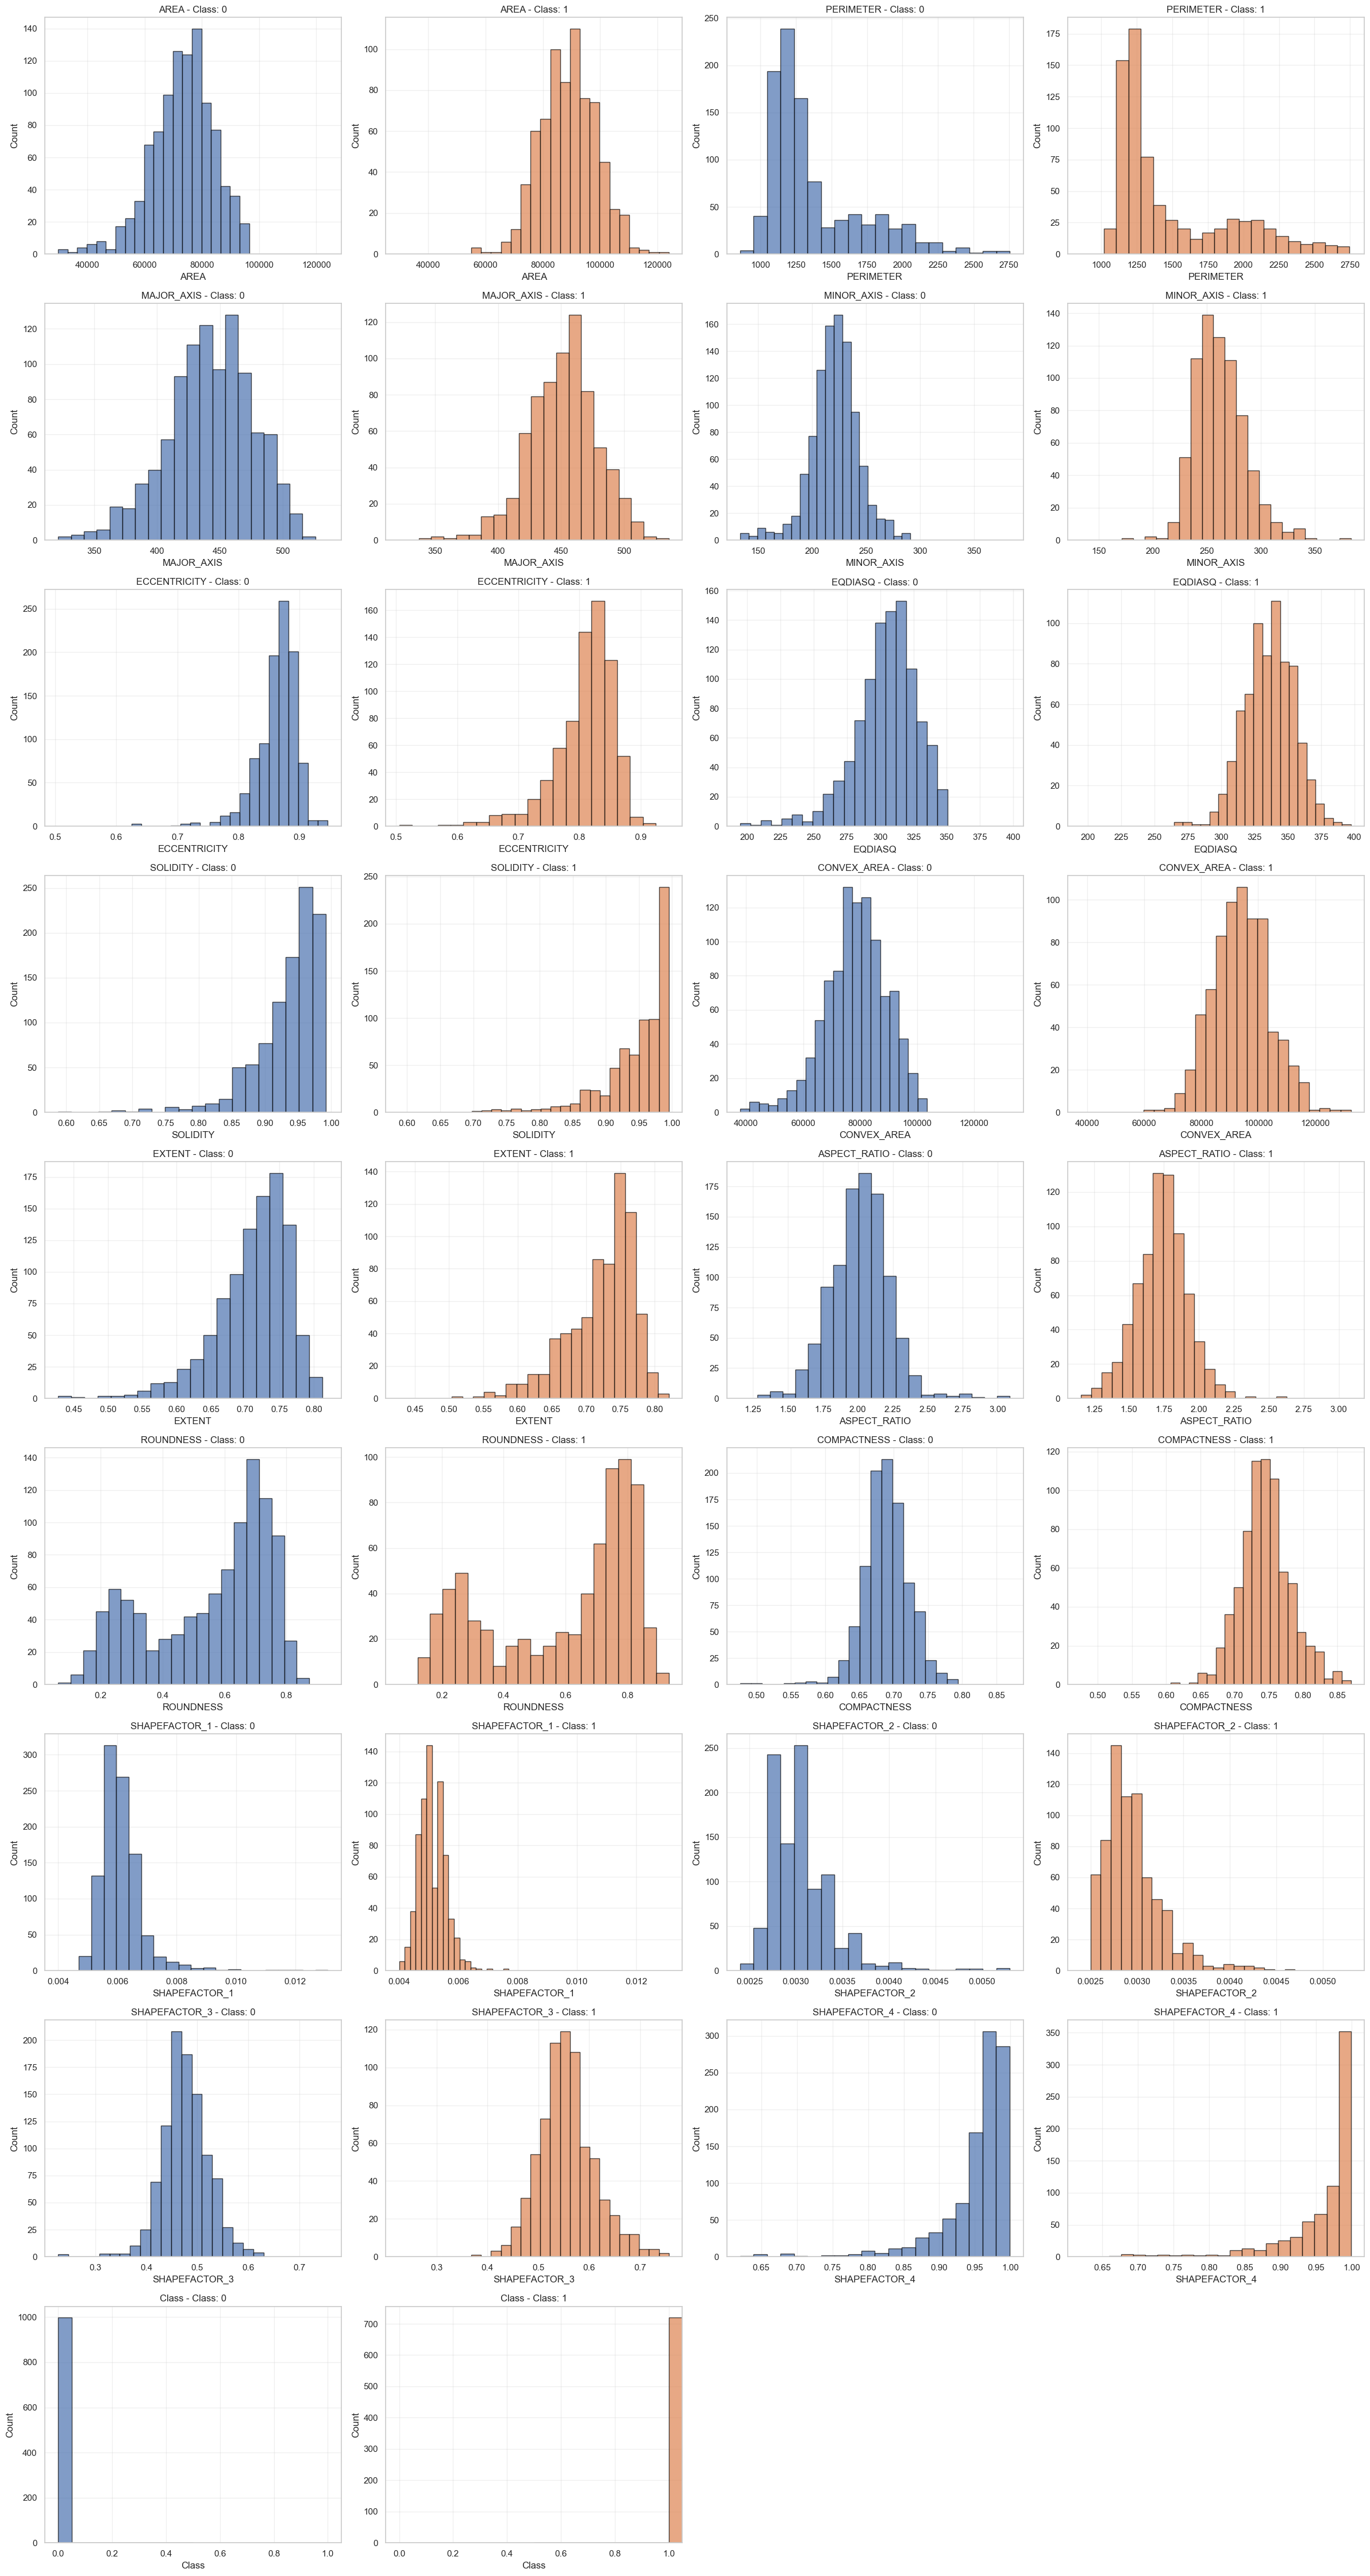

In [265]:
analyzer.plot_separate_histograms_by_class()

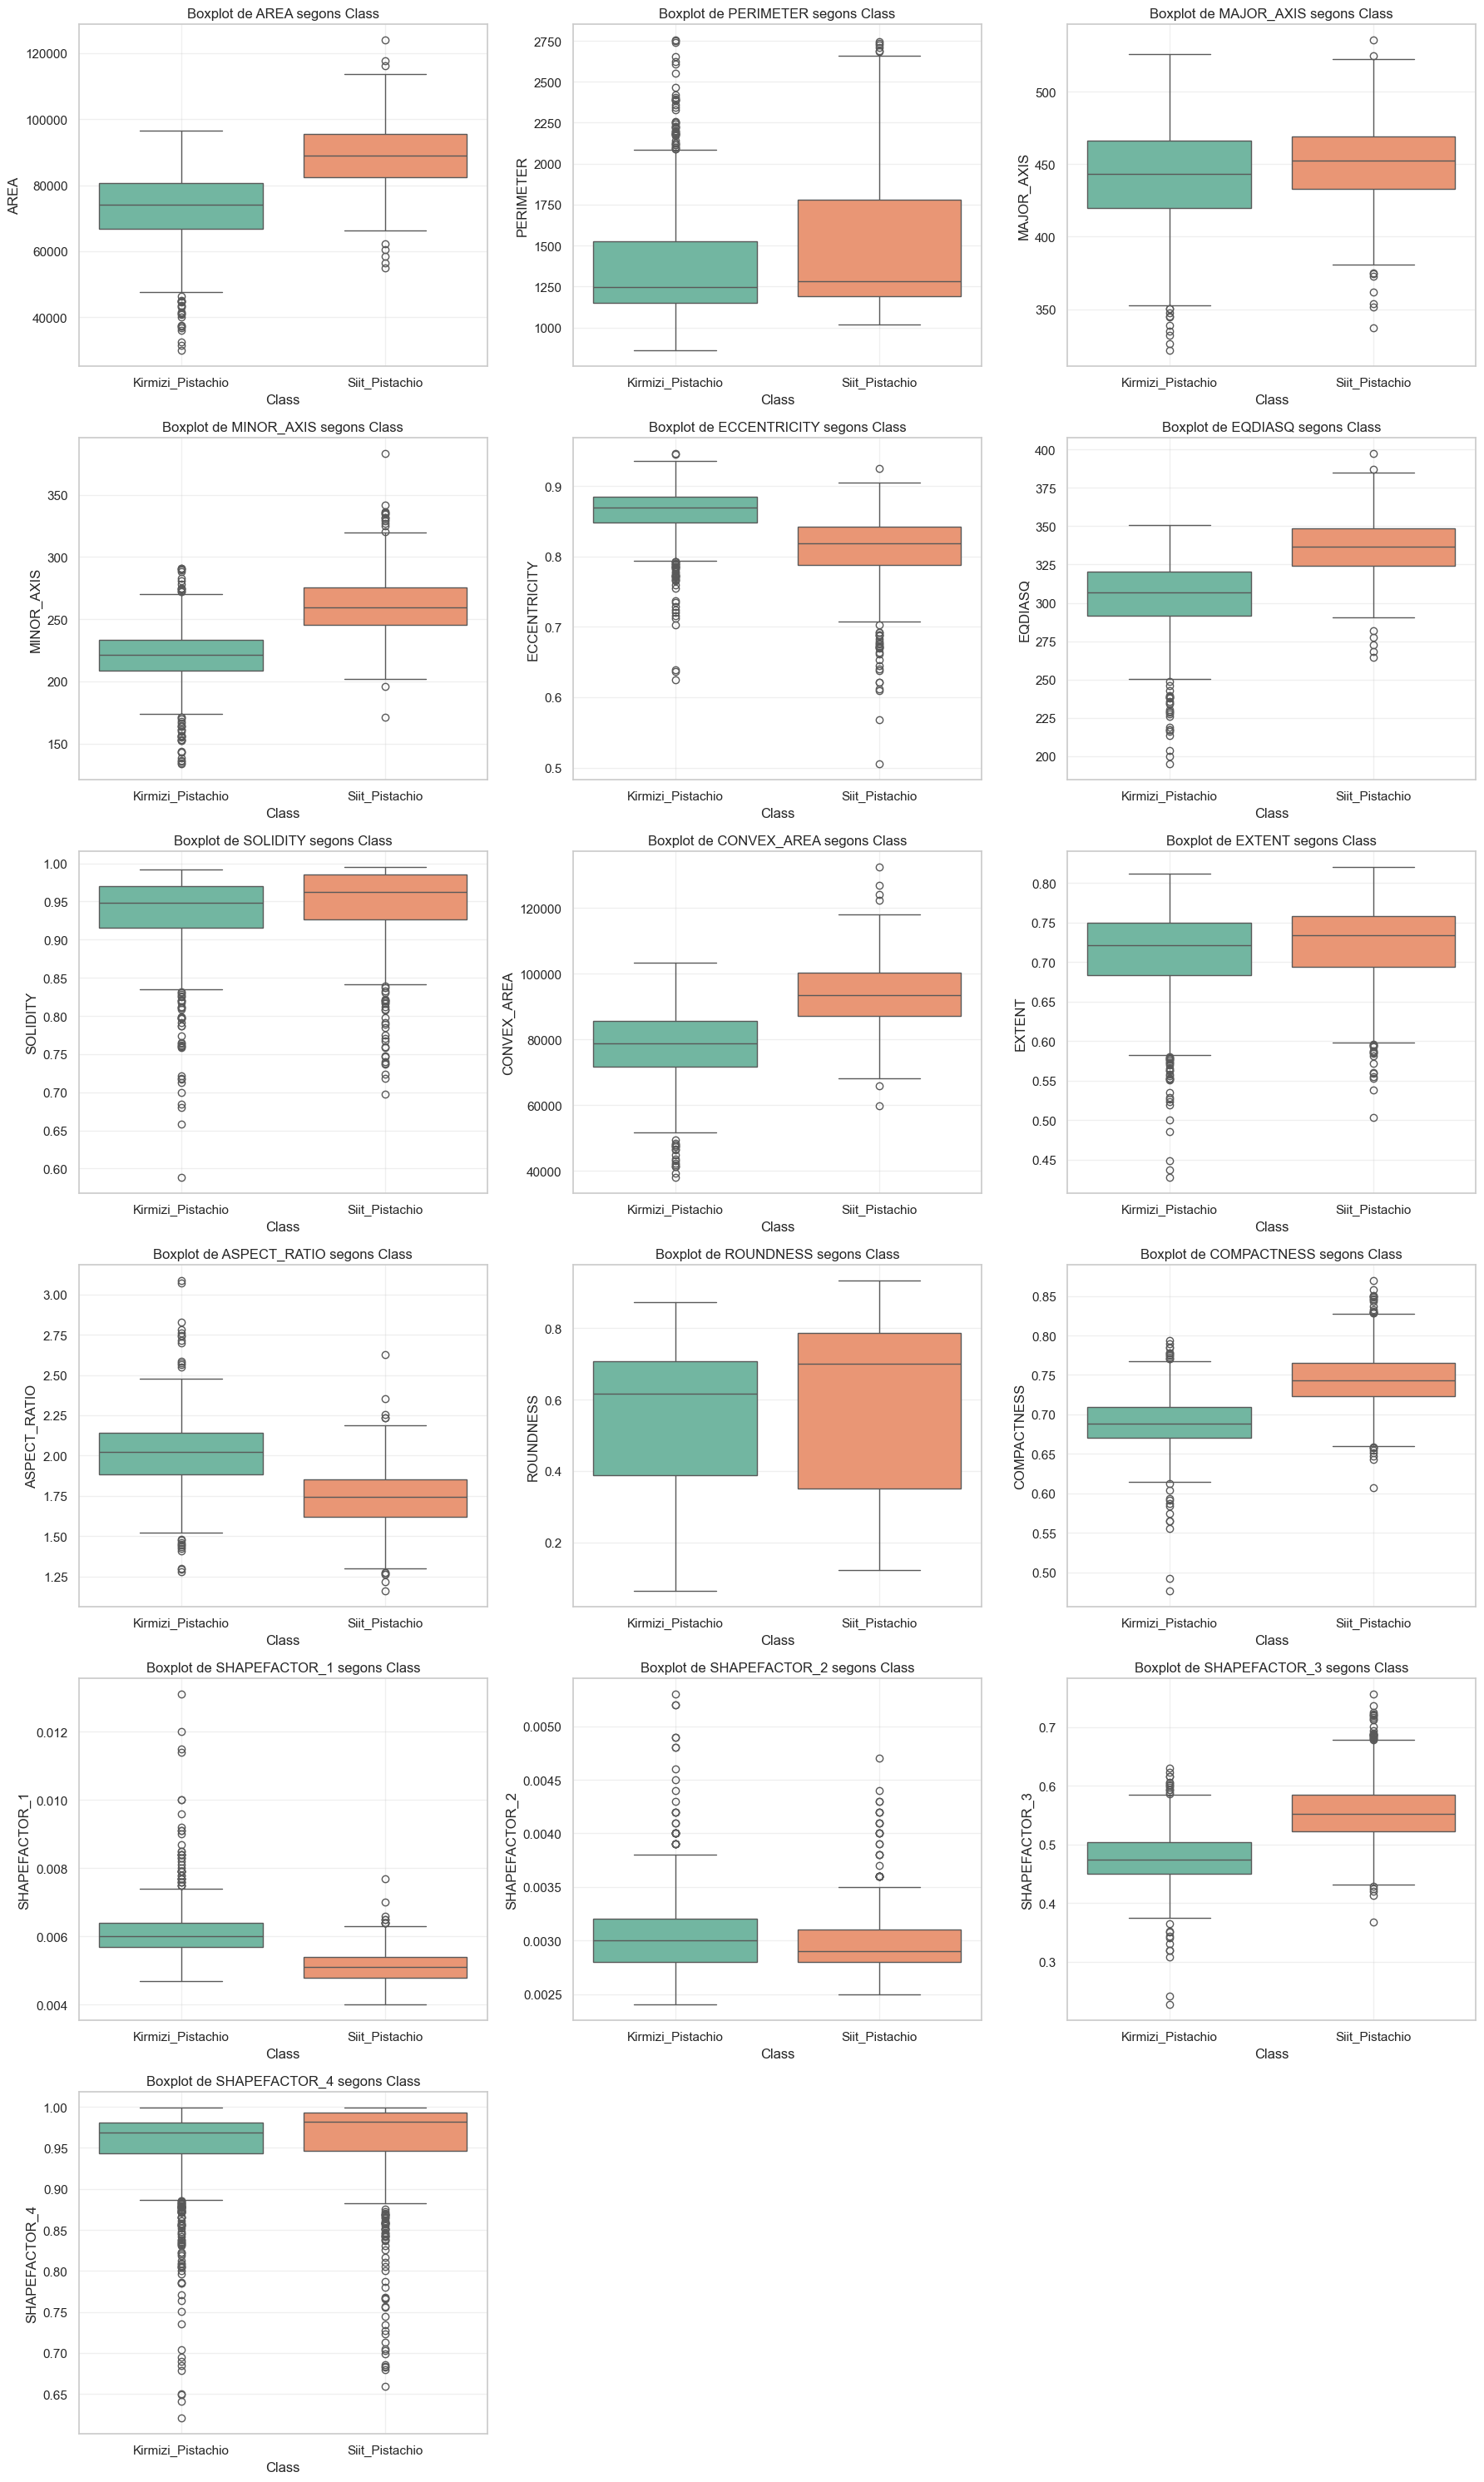

In [266]:
analyzer.plot_boxplots()

In [267]:
percentatges = df['Class'].value_counts(normalize=True) * 100
print(percentatges)


Class
Kirmizi_Pistachio    58.090803
Siit_Pistachio       41.909197
Name: proportion, dtype: float64


Veiem que les classes estàn una mica desbalancejades encara que no molt.

Observant els gràfics podem dir que les dades estàn bastant normalitzades, cosa que ens fa pensar que tindrem bons resultats en predir. També per algunes variables podem distingir valors lleugerament diferents segons la classe.


Creiem que moltes de les variables poden estar molt correlacionades, ja que moltes s'extreuen d'altres, per a comprovar això calculem el coeficient de correlació de Pearson entre tots els atributs.

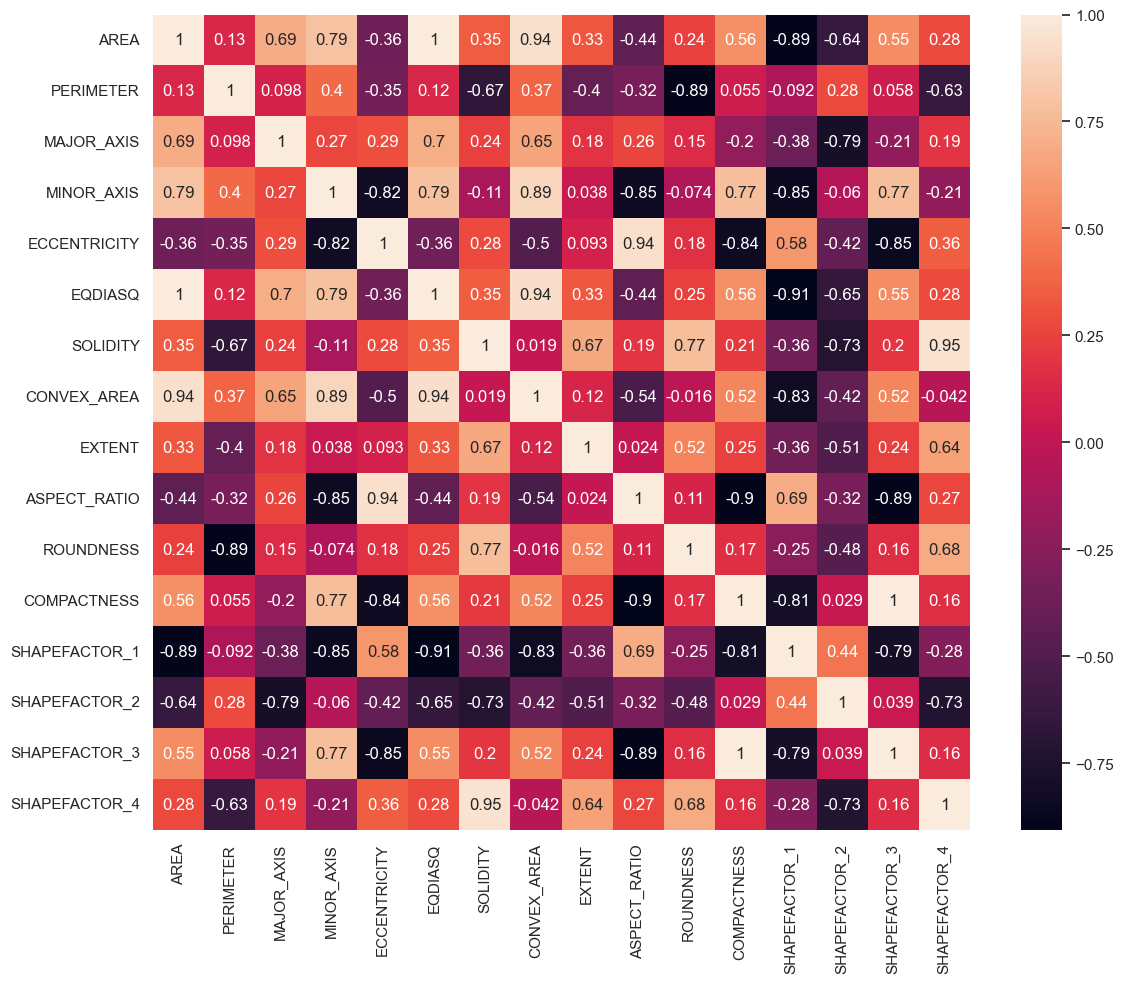

In [268]:
analyzer.plot_correlation_matrix()

Efectivament, hi ha moltes variables amb coeficients de correlació molt grans i segurament podem prescindir d'algunes sense perdre massa informació.

Utilitzarem `LabelEncoder()` per a transformar la variable objectiu a una variable numèrica que prengui valors `0` o `1`, per tal de poder comparar la correlació amb la resta de variables.

Ara podem generar un gràfic on es vegi la correlació de cada variable amb el target Class.

C:\Users\ricar\AppData\Local\Temp\ipykernel_18616\3640231023.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


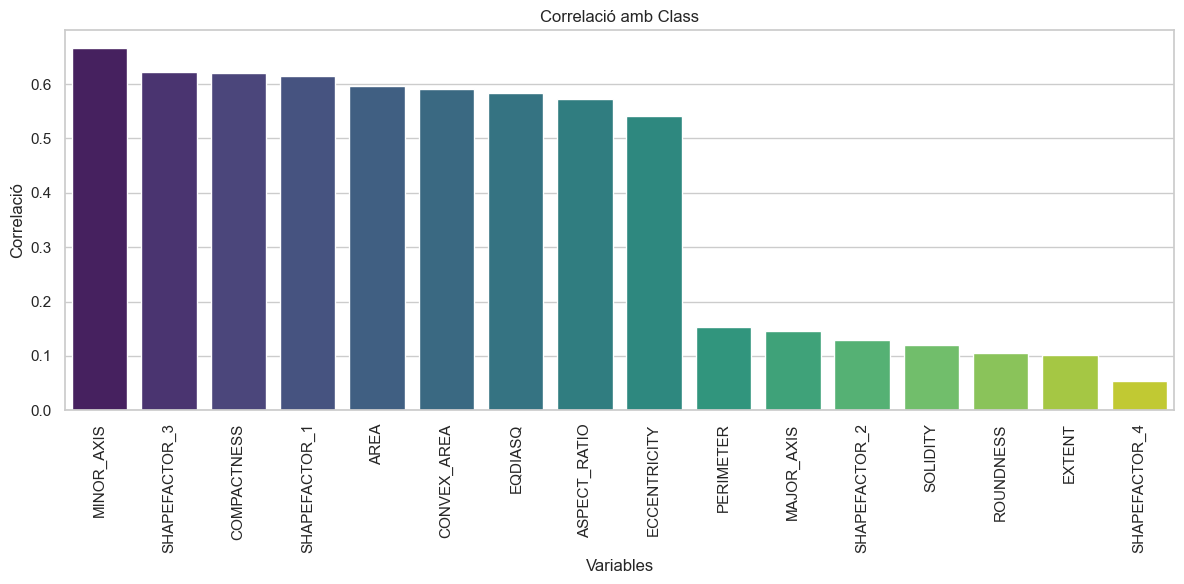

In [269]:
analyzer.plot_corr_with_target()


Decidirem de quines variables prescindir de la següent manera, triant un llindar, primer mirem quines tenen un coeficient de correlació molt alt entre elles, després, d'aquestes dues eliminem la que tingui una correlació menor amb la variable objectiu, així ens quedarem amb la que més informació ens aporta alhora de predir.

In [270]:
eliminades = analyzer.drop_highly_correlated(threshold=0.9)
print("Variables eliminades:", eliminades)

Variables eliminades: ['ECCENTRICITY', 'CONVEX_AREA', 'SHAPEFACTOR_4', 'COMPACTNESS', 'EQDIASQ']


Finalment implementem una funció que estandaritza els valors de totes les variables.

In [271]:
analyzer.estandaritzar_variables()

analyzer.df.describe(include="all")

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,SOLIDITY,EXTENT,ASPECT_RATIO,ROUNDNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,Class
count,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1.718000e+03,1718.000000
mean,-2.605599e-16,2.192012e-16,-1.091870e-15,5.417992e-16,8.013251e-16,-1.997626e-15,4.673535e-16,4.135872e-18,3.101904e-17,8.871445e-16,1.147704e-15,0.419092
std,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,1.000291e+00,0.493554
min,-3.861636e+00,-1.509334e+00,-3.914568e+00,-3.441546e+00,-7.043232e+00,-5.499993e+00,-3.071700e+00,-2.402576e+00,-2.105044e+00,-1.845605e+00,-4.473461e+00,0.000000
25%,-6.150247e-01,-6.755003e-01,-6.165239e-01,-6.679574e-01,-3.971200e-01,-5.322740e-01,-6.759053e-01,-9.387735e-01,-6.227340e-01,-6.493214e-01,-7.096361e-01,0.000000
50%,-5.935686e-03,-4.313207e-01,7.048258e-02,-7.575808e-02,2.739923e-01,1.912726e-01,8.627920e-04,3.453198e-01,-1.286308e-01,-5.117976e-02,-1.001498e-01,0.000000
75%,7.025406e-01,4.759747e-01,6.684880e-01,6.325451e-01,7.240676e-01,7.148919e-01,7.016791e-01,8.210763e-01,4.889982e-01,5.469619e-01,6.292613e-01,1.000000
max,3.404392e+00,3.571527e+00,2.805735e+00,4.762145e+00,1.100131e+00,1.986811e+00,4.919326e+00,1.715603e+00,9.135804e+00,6.827449e+00,3.881827e+00,1.000000


Hem vist que el dataset no està molt desequilibrat, però sí que tenim més Kirmizi que Siit.

1. Accuracy: Pot ser enganyosa en datasets desequilibrats.
   En el nostre cas el dataset té més Kirmizi, si per exemple, tinguèssim un model que predi sempre Kirmizi ens donaria un 0.58 d'accuracy quan realment no prediu mai bé Siit.

2. Precision i Recall: Serveixen més per avaluar el rendiment en la classe minoritària es a dir Siit.
   - Precision: Quants dels que prediu com a Siit són realment Siit (minimitzar falsos positius).
   - Recall mira quants dels Siit reals hem detectat (minimitzar falsos negatius).
   Ens caldria un equilibri ja que no ens interesa predir millor una classe que l'altra si no predir més o menys bé les dues. 

3. Average Precision Score (AUC-PR): Àrea sota la Precision-Recall curve.
   És útil quan el model retorna probabilitats i les classes són desequilibrades.
   En aquest cas, com les classes no són extremadament desequilibrades no l’hem triada.

4. ROC-AUC: Resumeix la capacitat del model per separar classes.
   Però és menys informativa que la Precision-Recall curve en casos desequilibrats, ja que pot donar una falsa sensació de bon rendiment quan hi ha molts negatius, ja que el FPR = FP / FP + TN pot ser baix simplement perquè hi ha molts negatius i per tant, TN. És el que ens podria passar aquí ja que tenim menys Siit que Kirmizi.

5. F1-score: Combina Precision i Recall, ens ajuda a no confondre un tipus de pistatxo amb l'altre i no deixar de perdre prediccions d'un dels dos tipus. 

Vis això, triem l'F1-score com a mètrica principal.

Ja tenim tot llest per entrenar diferents models, per a fer-ho més senzill hem dissenyat una classe que ens entreni el model que volguem.

In [272]:
class Model:
    """
    Classe per entrenar i predir diferents models
    """

    def __init__(self,
                 model_class=None,
                 dataframe: pd.DataFrame = None,
                 target: str = "Class",
                 hyperparameters: dict = None,
                 test_size: float = 0.2,
                 random_state: int = 42
                 ):
        """
        Inicialitza el model:
        - Guarda la classe del model sklearn, dataframe, variable objectiu i hiperparàmetres.
        - Separa X i y.
        - Fa l'split train/test.
        - Inicialitza variables internes.
        - Entrena el model.
        """

        self.model_class = model_class
        self.dataframe = dataframe
        self.target = target
        self.hyperparameters = hyperparameters or {}
        self.test_size = test_size
        self.random_state = random_state

        self.X = self.dataframe.drop(self.target, axis=1)
        self.y = self.dataframe[self.target]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=self.y
        )

        self.model = None
        self.y_pred = None
        self.y_pred_probs = None
        self.metrics = {}

        self.fit()

    def fit(self):
        """
        Crea i entrena el model sklearn amb els hiperparàmetres especificats.
        """
        self.model = self.model_class(**self.hyperparameters)
        self.model.fit(self.X_train, self.y_train)
        return self

    def predict(self, threshold=0.5):
        """
        Fa prediccions sobre les dades de test.
        Si el model suporta probabilitats, converteix a classes segons el threshold.
        Si no, fa predicció directa.
        """
        if self.model is None:
            self.fit()

        if hasattr(self.model, "predict_proba"):
            self.y_pred_probs = self.model.predict_proba(self.X_test)[:, 1]
            self.y_pred = (self.y_pred_probs >= threshold).astype(int)
        else:
            self.y_pred = self.model.predict(self.X_test)
            self.y_pred_probs = None

        return self.y_pred


I una altra classe que ens calcula les mètriques del nostre model i la matriu de confusió.

In [273]:
ACCURACY = "Accuracy"
PRECISION = "Precision"
RECALL = "Recall"
F1 = "F1"
AUC_ROC = "AUC-ROC"
AUC_PR = "AUC_PR"

In [274]:

class Metrics:
    """
    Classe per obtenir diferents mètriques a partir del nostre model entrenat
    """

    @staticmethod
    def evaluate(model: Model):
        """
        Rep una instància de Model (classe).
        Calcula i retorna un diccionari amb diverses mètriques.
        """

        if model.y_pred is None:
            model.predict()

        results = {
            ACCURACY: accuracy_score(model.y_test, model.y_pred),
            PRECISION: precision_score(model.y_test, model.y_pred),
            RECALL: recall_score(model.y_test, model.y_pred),
            F1: f1_score(model.y_test, model.y_pred),
        }
        
        if model.y_pred_probs is not None:
            try:
                results[AUC_ROC] = roc_auc_score(model.y_test, model.y_pred_probs)
                results[AUC_PR] = average_precision_score(model.y_test, model.y_pred_probs)
            except ValueError:
                # En cas que no sigui possible calcular AUC (ex: classes només d'una categoria)
                results[AUC_ROC] = None
                results[AUC_PR] = None
        else:
            results[AUC_ROC] = None
            results[AUC_PR] = None

        return results

    @staticmethod
    def confusion_matrix(model: Model):
        """
        Retorna la matriu de confusió per a la predicció del model.
        """
        if model.y_pred is None:
            model.predict()

        return confusion_matrix(model.y_test, model.y_pred)

    @staticmethod
    def summary(model: Model):
        """
        Mostra per pantalla les mètriques calculades.
        """
        metrics = Metrics.evaluate(model)
        for k, v in metrics.items():
            print(f"{k:12s}: {v:.4f}")


In [275]:
# Carreguem el dataset
df = pd.read_csv("./archive/pistachio.csv")

# Creem DatasetAnalyzer i eliminem variables correlacionades
analyzer = DatasetAnalyzer(df, target="Class")
variables_eliminades = analyzer.drop_highly_correlated(threshold=0.9)
print(f"Variables eliminades per alta correlació: {variables_eliminades}")
analyzer.estandaritzar_variables()


Variables eliminades per alta correlació: ['ECCENTRICITY', 'CONVEX_AREA', 'SHAPEFACTOR_4', 'COMPACTNESS', 'EQDIASQ']


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,SOLIDITY,EXTENT,ASPECT_RATIO,ROUNDNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,Class
0,-0.521808,-0.696465,-0.119182,-0.672868,0.045954,1.046200,0.549616,0.519118,0.488998,-0.051180,-0.544345,0
1,0.725064,-0.665996,0.440728,0.452418,0.480027,0.806287,-0.301190,1.155194,-0.622734,-0.649321,0.418209,1
2,-1.459141,-1.130481,-1.859758,-0.955619,0.127968,0.195081,-0.203754,0.924409,0.736050,1.145104,0.131021,0
3,-0.025836,0.047456,0.645966,-0.558214,0.071958,0.775822,0.874266,-0.418681,0.241947,-0.649321,-0.714764,0
4,1.274490,-0.185169,2.185546,0.276201,0.295996,0.509252,0.798804,0.431155,-0.375682,-1.247463,-0.771571,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1713,-1.103168,1.740282,-0.884070,-0.691946,-0.850196,-2.314484,0.106799,-1.791565,0.859576,0.846033,-0.509630,0
1714,-0.850245,0.052133,0.151815,-1.082855,-0.122074,-1.335792,1.236232,-0.729862,1.106627,-0.051180,-1.249692,0
1715,0.802044,-0.137315,-0.540934,1.039861,0.642054,0.455938,-1.283431,0.156389,-1.116837,-0.051180,1.806812,1
1716,-0.518646,-0.299905,0.716609,-0.982294,-0.050062,-1.560472,1.460543,-0.165669,0.859576,-0.649321,-1.369617,0


In [276]:
# Dataset net amb menys variables i normalitzat 
df_net = analyzer.df  

Provem a entrenar un model de regressió logística amb les classes que hem fet.

In [277]:
model = Model(
    model_class=LogisticRegression,   # classe sklearn
    dataframe=df_net,                 # dataframe pre-processat
    target="Class",                  # columna objectiu
    hyperparameters={"max_iter": 1000},  # hiperparàmetres del model
)

model.predict()

# Avaluem el model amb la classe Metrics
metrics_resultats = Metrics.evaluate(model)
Metrics.summary(model)  # imprimeix les mètriques


Accuracy    : 0.8634
Precision   : 0.8647
Recall      : 0.7986
F1          : 0.8303
AUC-ROC     : 0.9369
AUC_PR      : 0.9263


Creem una classe per a mostrar gràfics de les corves AUC-ROC i Precision-Recall, la matriu de confusió i un gràfic per a visualitzar les prediccions utilitzant 2 variables o PCA.

In [278]:
class Plotter:
    """
    Classe per a la visualització de diferents gràfics i la matriu de confusió.
    """

    @staticmethod
    def plot_roc(model: Model, plot_ax=None):
        """
        Mostra la corba ROC i mostra l'AUC-ROC del model.
        """
        if model.y_pred is None:
            model.predict()
        if not model.metrics:
            model.metrics = Metrics.evaluate(model)
        if plot_ax is None:
            _, plot_ax = plt.subplots()

        auc = model.metrics.get(AUC_ROC, None)
        title = f"{model.model_class.__name__}: ROC Curve (AUC: {auc:.4f})"

        fpr, tpr, _ = roc_curve(model.y_test, model.y_pred_probs)

        plot_ax.plot(fpr, tpr, color="darkorange", lw=2)
        plot_ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
        plot_ax.set_xlabel("False Positive Rate")
        plot_ax.set_ylabel("True Positive Rate")
        plot_ax.set_title(title)

    @staticmethod
    def plot_pr(model: Model, plot_ax=None):
        """
        Mostra la corba Precision-Recall i mostra l'AUC-PR del model.
        """
        if model.y_pred is None:
            model.predict()
        if not model.metrics:
            model.metrics = Metrics.evaluate(model)
        if plot_ax is None:
            _, plot_ax = plt.subplots()

        auc = model.metrics.get(AUC_PR, None)
        title = f"{model.model_class.__name__}: Precision-Recall Curve (AUC: {auc:.4f})"

        prec, recall, _ = precision_recall_curve(model.y_test, model.y_pred_probs)
        base = np.mean(model.y_test)

        plot_ax.plot(recall, prec, color="darkorange", lw=2)
        plot_ax.plot([0, 1], [base, base], color="navy", lw=2, linestyle="--")
        plot_ax.set_xlabel("Recall")
        plot_ax.set_ylabel("Precision")
        plot_ax.set_title(title)

    @staticmethod
    def plot_confusion_matrix(model: Model, plot_ax=None):
        """
        Mostra la matriu de confusió del model.
        """
        if model.y_pred is None:
            model.predict()
        if plot_ax is None:
            _, plot_ax = plt.subplots()

        title = f"{model.model_class.__name__}: Confusion Matrix"

        disp = ConfusionMatrixDisplay(Metrics.confusion_matrix(model))
        disp.plot(ax=plot_ax, cmap="Blues", values_format="d")
        plot_ax.set_title(title)

    @staticmethod
    def plot_decision_boundary(model: Model, plot_ax=None, features: list = None, pca: bool = False):
        """
        Visualitza la frontera de decisió del model en 2D.
        - features: llista de dues columnes per a visualitzar
        - pca: si True, aplica PCA per reduir dimensionalitat a 2D
        """
        if model.y_pred is None:
            model.predict()

        X = model.X_test.values
        y = model.y_test.values
        feature_names = model.X_test.columns

        if features is not None and len(features) == 2:
            i, j = feature_names.get_loc(features[0]), feature_names.get_loc(features[1])
            X_vis = X[:, [i, j]]
            xlabel, ylabel = feature_names[i], feature_names[j]
        elif pca:
            from sklearn.decomposition import PCA
            pca_model = PCA(n_components=2)
            X_vis = pca_model.fit_transform(X)
            xlabel, ylabel = "PC1", "PC2"
            i, j = None, None
        else:
            if X.shape[1] > 2:
                print(f"Dades amb {X.shape[1]} dimensions. Indica 'features=[...]' o 'pca=True' per visualitzar en 2D.")
                return
            X_vis = X
            xlabel, ylabel = feature_names[0], feature_names[1]
            i, j = 0, 1

        if plot_ax is None:
            _, plot_ax = plt.subplots(figsize=(7, 5))

        f1 = Metrics.evaluate(model)[F1]
        title = f"{model.model_class.__name__}: Decision Boundary (F1: {f1:.4f})"

        h = 0.02  # resolució del grid
        x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
        y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

        # Creem un grid on canviarem només les dues variables d'interès
        X_mean = model.X_test.mean().values
        X_grid = np.tile(X_mean, (xx.size, 1))

        if pca:
            grid_proj = pca_model.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
            Z = model.model.predict(grid_proj)
        else:
            X_grid[:, i] = xx.ravel()
            X_grid[:, j] = yy.ravel()
            Z = model.model.predict(X_grid)

        Z = Z.reshape(xx.shape)

        plot_ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        plot_ax.scatter(X_vis[y == 0, 0], X_vis[y == 0, 1], c="blue", edgecolors="k", label="Classe 0")
        plot_ax.scatter(X_vis[y == 1, 0], X_vis[y == 1, 1], c="red", edgecolors="k", label="Classe 1")

        plot_ax.set_xlabel(xlabel)
        plot_ax.set_ylabel(ylabel)
        plot_ax.set_title(title)
        plot_ax.legend()

Amb tot això podem visualtizar les corbes ROC i PR juntament amb la matriu de confusió.

A més a més hem decidit crear uns gràfics per a poder visualitzar com pren les decisions el nostre model si reduïm la dimensinalitat a dues variables o apliquem PCA.

c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


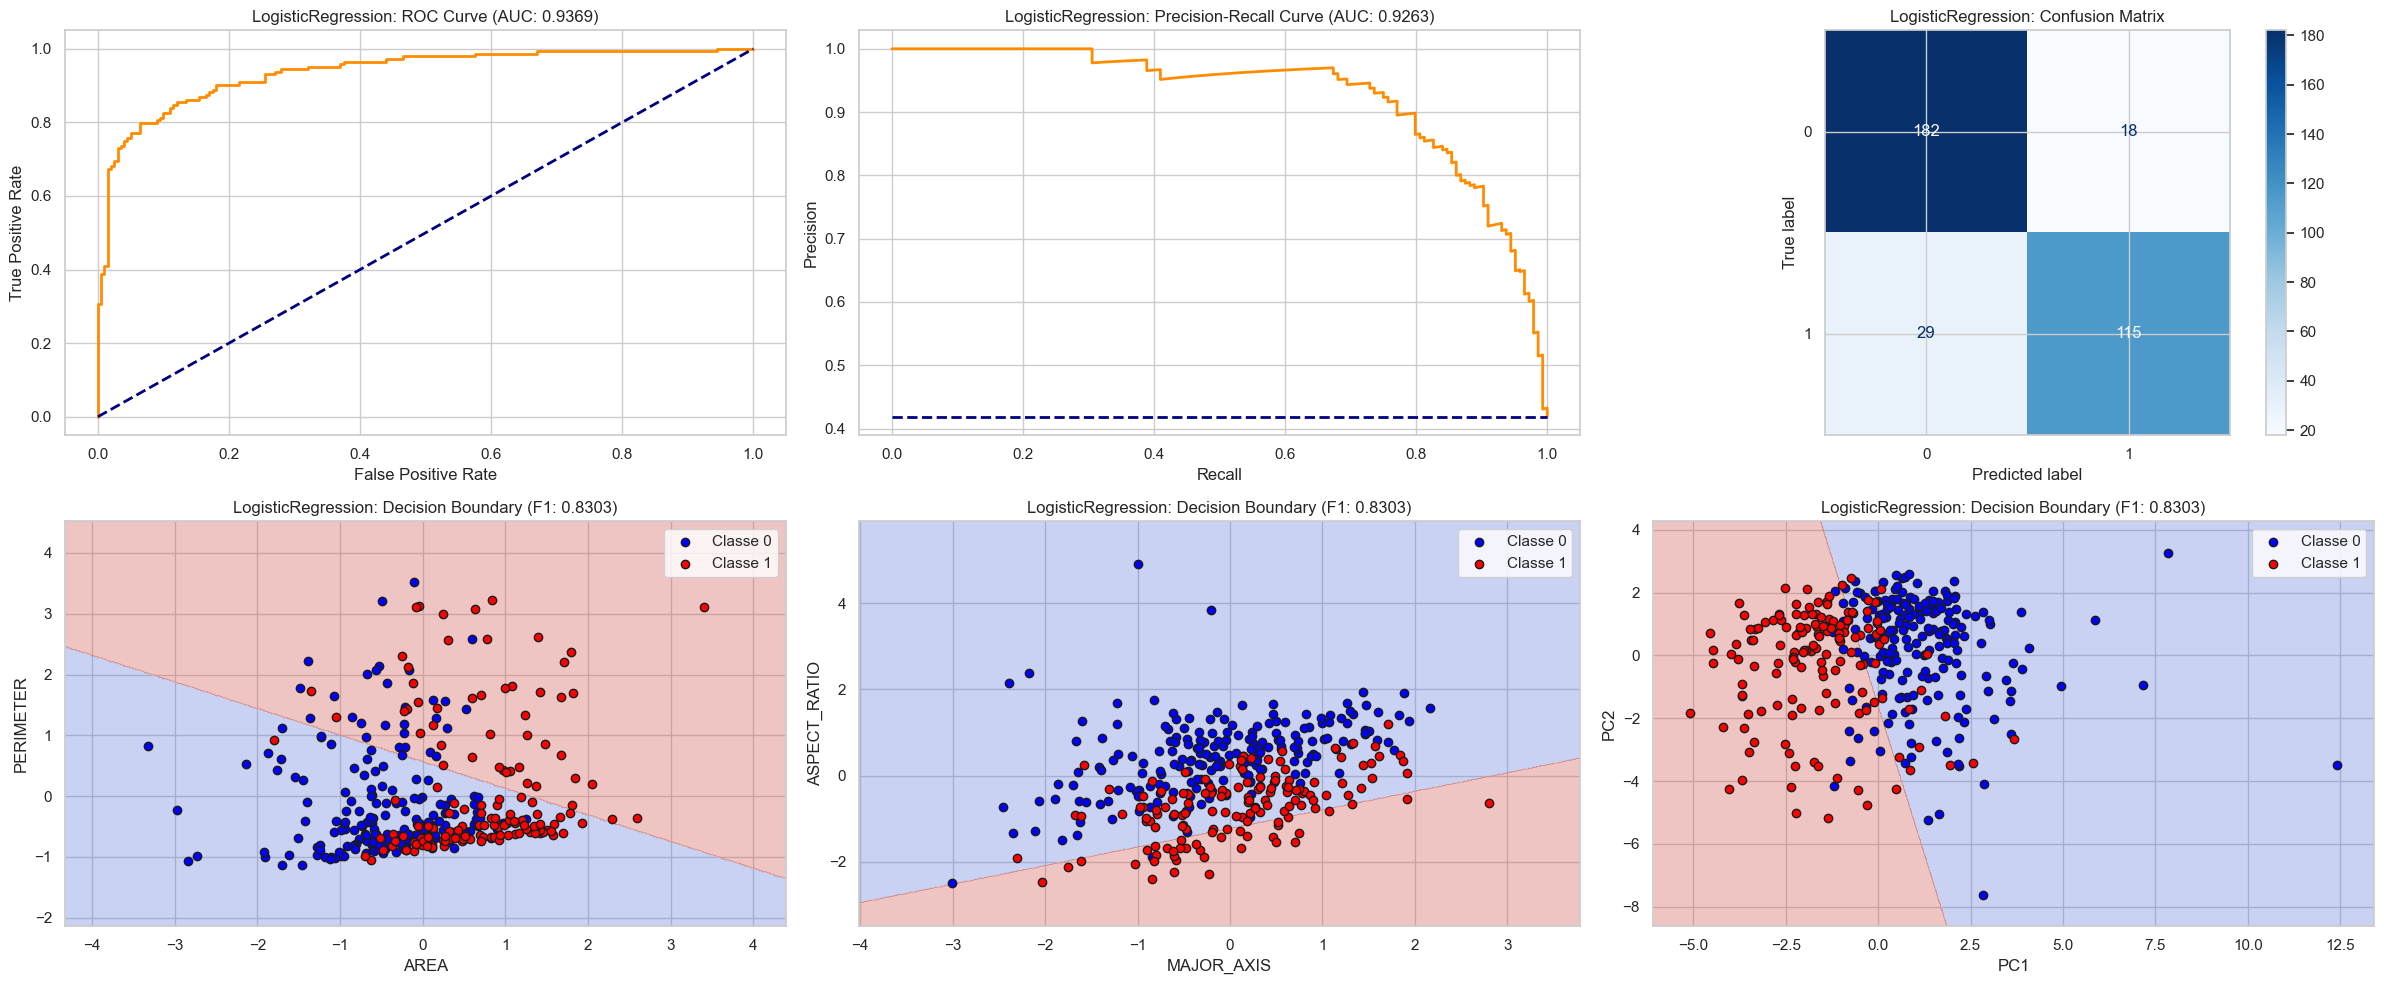

In [279]:
fig, axes = plt.subplots(2, 3, figsize=(24, 10))
axes_iter = iter(axes.flatten())

Plotter.plot_roc(model, plot_ax=next(axes_iter))
Plotter.plot_pr(model, plot_ax=next(axes_iter))
Plotter.plot_confusion_matrix(model, plot_ax=next(axes_iter))
Plotter.plot_decision_boundary(model, features=["AREA", "PERIMETER"], plot_ax=next(axes_iter))
Plotter.plot_decision_boundary(model, features=["MAJOR_AXIS", "ASPECT_RATIO"], plot_ax=next(axes_iter))
Plotter.plot_decision_boundary(model, pca=True, plot_ax=next(axes_iter))

plt.tight_layout()

Validació creuada: Utilitzarem validació creuada per a tenir uns resultats més robusts, fent que tots els models utilitzin totes les dades tant per entrenar com per fer el test.

- `K-Fold`: Es divideix el dataset en K parts iguals, en cada iteració s’entrena amb K-1 parts, es valida amb la part restant, es repeteix K vegades.
- `Stratified K-Fold`: Funciona igual que K-Fold però manté la proporció de classes dins de les parts que separa.
- `Repeated Stratified K-Fold`: Fa un Startified K-Fold però el repeteix varies vegades fent diferents particions.
- `Shuffle & Split`: Es trien conjunts de test i entrenament de forma aleatòria varies vegades.

In [280]:
KFOLD = "K-Fold"
STRATIFIED = "Stratified K-Fold"
REPEATED = "Repeated Stratified K-Fold"
SHUFFLE = "Shuffle & Split"

CROSS_VALIDATORS = [
    KFOLD,
    STRATIFIED,
    REPEATED,
    SHUFFLE,
]

In [281]:
class CValidator:
    @staticmethod
    def cross_validation(
        model_class,
        dataframe: pd.DataFrame,
        target: str,
        hyperparameters: dict = None,
        cv_method: str = "kfold",
        scoring: str = "f1",
        folds: int = 5,
        n_repeats: int = 3,
        test_size: float = 0.2,
        random_state: int = 42
    ):
        """
        Fa cross-validation de manera independent (no demana un model entrenat).

        Paràmetres:
        - model_class: classe del model (ex: RandomForestClassifier)
        - dataframe: dataset complet
        - target: columna objectiu
        - hyperparameters: diccionari d'hiperparàmetres per crear el model
        - method: 'kfold', 'stratified', 'repeated', 'shuffle'
        - scoring: mètrica sklearn ('accuracy', 'f1', etc.)
        """

        hyperparameters = hyperparameters or {}

        # Separar X i y
        X = dataframe.drop(target, axis=1)
        y = dataframe[target]

        # Seleccionar el mètode de CV
        cv_methods = {
            KFOLD: KFold(n_splits=folds, shuffle=True, random_state=random_state),
            STRATIFIED: StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state),
            REPEATED: RepeatedStratifiedKFold(n_splits=folds, n_repeats=n_repeats, random_state=random_state),
            SHUFFLE: ShuffleSplit(n_splits=folds, test_size=test_size, random_state=random_state),
        }

        if cv_method not in cv_methods:
            raise ValueError(f"cv_method must be one of: {list(cv_methods.keys())}")
        
        cv_splitter = cv_methods[cv_method]

        # Fer el CV
        results = cross_validate(
            estimator=model_class(**hyperparameters),
            X=X,
            y=y,
            cv=cv_splitter,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        df_results = pd.DataFrame(results)

        # Resum
        summary = {
            "Fit Time (mean)": df_results["fit_time"].mean(),
            "Score Time (mean)": df_results["score_time"].mean(),
            "Train Score (mean)": df_results["train_score"].mean(),
            "Test Score (mean)": df_results["test_score"].mean(),
        }

        return summary, df_results



`Regressió Logística`
És un model de classificació lineal que estima la probabilitat que una mostra pertanyi a una classe mitjançant una funció logística. És simple, ràpid d’entrenar i funciona molt bé quan les dades són separables linealment. 

`K-Nearest Neighbors (KNN)`
És un model basat en la distància entre mostres. Classifica cada nova dada segons la classe majoritària dels seus K veïns més propers. No necessita una fase d’entrenament real, però pot ser lent en predicció ja que ha de comparar cada mostra amb totes les dades existents.

`Support Vector Machine (SVM)`
És un model que busca el millor hiperpla possible per separar les classes maximitzant el marge entre elles. Pot treballar amb fronteres no lineals mitjançant kernels. 

`Random Forest`
És un model basat en un conjunt d’arbres de decisió entrenats de manera aleatòria. Cada arbre vota una classe i el resultat final és la decisió majoritària. 

`Gradient Boosting`
És un model d’arbres seqüencials on cada arbre corregeix els errors de l’anterior. És molt potent i capaç d’obtenir un rendiment molt alt, però és sensible als hiperparàmetres i pot sobreajustar si no es controla correctament.


In [282]:
LOGISTIC_REGRESSION = "Regressió Logística"
KNN = "KNN"
SVM = "SVM"
RANDOM_FOREST = "Random Forest"
GRADIENT_BOOSTING = "Gradient Boosting"

# Diccionari de models sklearn
MODELS = {
    LOGISTIC_REGRESSION: LogisticRegression,
    KNN: KNeighborsClassifier,
    SVM: SVC,
    RANDOM_FOREST: RandomForestClassifier,
    GRADIENT_BOOSTING: GradientBoostingClassifier,
}

Entrenem tots els models amb els diferents mètodes de Cross-Validation, el score (mètrica) que ens retornarà serà l'F1-score com hem triat abans.

In [283]:
results = []

for model_name, model_class in MODELS.items():

    with tqdm(CROSS_VALIDATORS, desc=f"Cross-validating {model_name}", leave=False) as pbar:
        for method in pbar:
            pbar.set_postfix({"validator": method})

            summary, _ = CValidator.cross_validation(
                model_class=model_class,
                dataframe=df_net,
                target="Class",
                cv_method=method,
                scoring="f1"
            )

            summary["Model"] = model_name
            summary["Validator"] = method
            results.append(summary)

results_df = pd.DataFrame(results)
results_df.set_index(["Model", "Validator"], inplace=True)

display(results_df)

Fit Time (mean)  ...  Test Score (mean)
Model               Validator                                    ...                   
Regressió Logística K-Fold                             0.014805  ...           0.846541
                    Stratified K-Fold                  0.017116  ...           0.844179
                    Repeated Stratified K-Fold         0.021594  ...           0.843072
                    Shuffle & Split                    0.019208  ...           0.852673
KNN                 K-Fold                             0.008183  ...           0.821091
                    Stratified K-Fold                  0.009080  ...           0.832420
                    Repeated Stratified K-Fold         0.010685  ...           0.831323
                    Shuffle & Split                    0.008137  ...           0.841333
SVM                 K-Fold                             0.060792  ...           0.850133
                    Stratified K-Fold                  0.066762  ...           0.852852
                    Repeated Stratified K-Fold         0.080156  ...           0.852156
                    Shuffle & Split                    0.075249  ...           0.856393
Random Forest       K-Fold                             0.748400  ...           0.831415
                    Stratified K-Fold                  0.826832  ...           0.840917
                    Repeated Stratified K-Fold         1.271621  ...           0.834769
                    Shuffle & Split                    0.738147  ...           0.841063
Gradient Boosting   K-Fold                             1.045043  ...           0.837347
                    Stratified K-Fold                  1.047015  ...           0.836145
                    Repeated Stratified K-Fold         1.567072  ...           0.838084
                    Shuffle & Split                    1.041438  ...           0.840873

[20 rows x 4 columns]

A més a més, hem intentat provar diferents combinacions amb menys variables per tal de veure si obtenim bons resultats sense necessitar tantes dades.

In [284]:
results = []

cols = df_net.drop("Class", axis=1).columns.tolist()
n = 4

for model_name, model_class in MODELS.items():
    print(f"Processant model: {model_name}")

    # Itera totes les combinacions de 1 a n variables
    features_combinations = []
    for r in range(1, n):
        features_combinations.extend(combinations(cols, r))

    for features in tqdm(features_combinations, desc=f"Features - {model_name}", leave=False):
        # Retorna nou dataset amb només aquestes features + target
        df_subset = DatasetAnalyzer(df_net).update_dataset(features=list(features))

        # Creem un model nou amb aquest dataset
        model = Model(
            model_class=model_class,
            dataframe=df_subset,
            target="Class",
        )

        # Predir i avaluar
        model.predict()
        metrics = Metrics.evaluate(model)

        results.append({"Model": model_name, "Features": features, **metrics})

results_df = pd.DataFrame(results)
display(results_df)
display(results_df.describe())


Processant model: Regressió Logística


Features - Regressió Logística:   1%|▏         | 3/231 [00:00<00:09, 23.88it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Features - Regressió Logística:   3%|▎         | 6/231 [00:00<00:08, 26.43it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_cla

Processant model: KNN


Processant model: SVM


Features - SVM:   1%|          | 2/231 [00:00<00:37,  6.15it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Features - SVM:   2%|▏         | 5/231 [00:00<00:35,  6.31it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Features - SVM:   3%|▎         | 8/231 [00:01<00:33,  6.72it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\sit

Processant model: Random Forest


Processant model: Gradient Boosting


,Model,Features,Accuracy,Precision,Recall,F1,AUC-ROC,AUC_PR
0,Regressió Logística,"(AREA,)",0.787791,0.793388,0.666667,0.724528,0.874757,0.859245
1,Regressió Logística,"(PERIMETER,)",0.598837,0.557692,0.201389,0.295918,0.567431,0.498732
2,Regressió Logística,"(MAJOR_AXIS,)",0.561047,0.422222,0.131944,0.201058,0.552674,0.459708
3,Regressió Logística,"(MINOR_AXIS,)",0.825581,0.838710,0.722222,0.776119,0.916597,0.887657
4,Regressió Logística,"(SOLIDITY,)",0.581395,0.000000,0.000000,0.000000,0.639687,0.612967
...,...,...,...,...,...,...,...,...
1150,Gradient Boosting,"(ASPECT_RATIO, SHAPEFACTOR_2, SHAPEFACTOR_3)",0.875000,0.853147,0.847222,0.850174,0.937170,0.933627
1151,Gradient Boosting,"(ROUNDNESS, SHAPEFACTOR_1, SHAPEFACTOR_2)",0.872093,0.862319,0.826389,0.843972,0.935642,0.921991
1152,Gradient Boosting,"(ROUNDNESS, SHAPEFACTOR_1, SHAPEFACTOR_3)",0.851744,0.839416,0.798611,0.818505,0.934965,0.921844
1153,Gradient Boosting,"(ROUNDNESS, SHAPEFACTOR_2, SHAPEFACTOR_3)",0.863372,0.843972,0.826389,0.835088,0.933472,0.920847


,Accuracy,Precision,Recall,F1,AUC-ROC,AUC_PR
count,1155.000000,1155.000000,1155.000000,1155.000000,924.000000,924.000000
mean,0.808877,0.789672,0.721356,0.748708,0.865135,0.832745
std,0.086231,0.122366,0.165314,0.154044,0.103801,0.124908
min,0.470930,0.000000,0.000000,0.000000,0.474132,0.400729
25%,0.802326,0.774667,0.743056,0.759452,0.868941,0.829532
50%,0.845930,0.834586,0.784722,0.811388,0.908559,0.878577
75%,0.860465,0.859259,0.805556,0.829449,0.925421,0.913747
max,0.889535,1.000000,0.854167,0.860294,0.945417,0.933627


In [285]:
results_df \
        .sort_values(by=["Model", "F1"], ascending=[True, False]) \
        .groupby("Model", group_keys=False) \
        .head(5) \
        .reset_index(drop=True)

,Model,Features,Accuracy,Precision,Recall,F1,AUC-ROC,AUC_PR
0,Gradient Boosting,"(AREA, ASPECT_RATIO, SHAPEFACTOR_3)",0.880814,0.865248,0.847222,0.856140,0.935920,0.927688
1,Gradient Boosting,"(PERIMETER, ROUNDNESS, SHAPEFACTOR_1)",0.880814,0.881481,0.826389,0.853047,0.945417,0.930184
2,Gradient Boosting,"(AREA, PERIMETER, ASPECT_RATIO)",0.877907,0.864286,0.840278,0.852113,0.933090,0.929261
3,Gradient Boosting,"(ASPECT_RATIO, SHAPEFACTOR_2, SHAPEFACTOR_3)",0.875000,0.853147,0.847222,0.850174,0.937170,0.933627
4,Gradient Boosting,"(PERIMETER, SHAPEFACTOR_1)",0.877907,0.875000,0.826389,0.850000,0.944948,0.932227
5,KNN,"(PERIMETER, SHAPEFACTOR_1)",0.877907,0.880597,0.819444,0.848921,0.917552,0.877285
6,KNN,"(EXTENT, SHAPEFACTOR_1, SHAPEFACTOR_2)",0.875000,0.874074,0.819444,0.845878,0.909670,0.883704
7,KNN,"(MINOR_AXIS, SOLIDITY, ROUNDNESS)",0.869186,0.866667,0.812500,0.838710,0.913333,0.862105
8,KNN,"(EXTENT, ASPECT_RATIO, SHAPEFACTOR_2)",0.869186,0.872180,0.805556,0.837545,0.906285,0.868865
9,KNN,"(SOLIDITY, ROUNDNESS, SHAPEFACTOR_1)",0.866279,0.865672,0.805556,0.834532,0.914375,0.872980


In [286]:
class HyperParameterOptimization:
    @staticmethod
    def grid_search(model: Model, param_grid: dict, scoring: str = "f1", cv=None):
        """
        Fa una cerca exhaustiva de hiperparàmetres (Grid Search) sobre un model.

        Paràmetres:
        - model: instància de la classe Model
        - param_grid: diccionari amb els hiperparàmetres a provar
        - scoring: mètrica sklearn per avaluar
        - cv: cross-validator (per defecte RepeatedStratifiedKFold)

        Retorna:
        - DataFrame amb els resultats de la cerca
        """
        # Crear cv si no s'especifica
        if cv is None:
            cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=model.random_state)

        # Crear el model sklearn amb els hiperparàmetres actuals
        base_estimator = model.model_class(**model.hyperparameters)

        searcher = GridSearchCV(
            estimator=base_estimator,
            param_grid=param_grid,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            return_train_score=True,
            error_score=np.nan
        )

        # Entrenar cerca sobre dades d'entrenament
        searcher.fit(model.X_train, model.y_train)

        # Actualitzar el model amb els millors hiperparàmetres
        model.hyperparameters = searcher.best_params_
        model.model_class = searcher.best_estimator_
        model.model_class.fit(model.X_train, model.y_train)
        model.valid_pred = False

        # Guardar resultats
        model.search_results_ = pd.DataFrame(searcher.cv_results_)

        return model.search_results_

In [287]:
# Grids d'hiperparàmetres
param_grids = {
    LOGISTIC_REGRESSION: {
        "penalty": ["l2"],
        "C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
        "max_iter": [100, 200, 500, 1000]
    },
    KNN: {
        "n_neighbors": range(1,21),
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    SVM: {
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "kernel": ["linear", "rbf", "poly", "sigmoid"],
        "gamma": ["scale", "auto"],
        "degree": [3, 4, 5]
    },
    RANDOM_FOREST: {
        "n_estimators": [10, 20, 50, 100, 200],
        "max_depth": [None, 2, 5, 10, 15],
        "min_samples_leaf": [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    GRADIENT_BOOSTING: {
        "n_estimators": range(80, 150, 10),
        "learning_rate": [0.1, 0.5, 1],
        "max_depth": [2, 3, 4, 5, 6],
    }
}

In [288]:
def count_param_combinations(param_grid):
    if isinstance(param_grid, dict):
        param_grid = [param_grid]
    total = 0
    for grid in param_grid:
        lengths = [len(v) for v in grid.values()]
        total += 1 if not lengths else int(np.prod(lengths))
    return total

results = {}
opt_params = {}
opt_models = {}

for model_name, model_class in MODELS.items():
    param_grid = param_grids.get(model_name)
    total_combinations = count_param_combinations(param_grid)

    with tqdm(total=total_combinations, desc=f"{model_name} combinacions") as bar:
        model = Model(model_class=model_class, dataframe=df_net)
        results[model_name] = HyperParameterOptimization.grid_search(model, param_grid=param_grid, scoring="f1")
        bar.update(total_combinations)  

    opt_params[model_name] = model.hyperparameters
    opt_models[model_name] = model


Gradient Boosting combinacions: 100%|██████████| 105/105 [04:35<00:00,  2.62s/it]


In [289]:
import pandas as pd

best_scores = {}
best_params = {}

for model_name, model in opt_models.items():
    best_scores[model_name] = model.search_results_["mean_test_score"].max()
    best_params[model_name] = model.hyperparameters

best_results_df = pd.DataFrame({
    "mean_test_score": best_scores,
    "best_params": best_params
})

pd.set_option('display.max_colwidth', None)
display(best_results_df)


,mean_test_score,best_params
Regressió Logística,0.843388,"{'C': 1000, 'max_iter': 100, 'penalty': 'l2'}"
KNN,0.841046,"{'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}"
SVM,0.850902,"{'C': 1, 'degree': 3, 'gamma': 'auto', 'kernel': 'rbf'}"
Random Forest,0.841431,"{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 50}"
Gradient Boosting,0.841521,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 90}"


In [290]:
class ModelPerformanceVisualizer:
    def __init__(self, models, dataframe, target, cv_method=REPEATED, folds=5, n_repeats=3):
        self.models = models
        self.dataframe = dataframe
        self.target = target
        self.cv_method = cv_method
        self.folds = folds
        self.n_repeats = n_repeats
        
        self.names = []
        # Preparar dict amb mètriques per model i per tipus (train/test)
        self.metrics = {
            'train_accuracy': [],
            'test_accuracy': [],
            'train_precision': [],
            'test_precision': [],
            'train_recall': [],
            'test_recall': [],
            'train_f1': [],
            'test_f1': []
        }
        
        # Map cv_method string to sklearn CV classes
        self.cv_mapping = {
            KFOLD: KFold,
            STRATIFIED: StratifiedKFold,
            REPEATED: RepeatedStratifiedKFold,
            SHUFFLE: ShuffleSplit
        }

    def run_evaluation(self):
        X = self.dataframe.drop(columns=[self.target])
        y = self.dataframe[self.target]

        cv_class = self.cv_mapping.get(self.cv_method, StratifiedKFold)

        if self.cv_method == REPEATED:
            cv = cv_class(n_splits=self.folds, n_repeats=self.n_repeats, random_state=42)
        elif self.cv_method in [KFOLD, STRATIFIED]:
            cv = cv_class(n_splits=self.folds, shuffle=True, random_state=42)
        elif self.cv_method == SHUFFLE:
            cv = cv_class(n_splits=self.folds, test_size=0.2, random_state=42)
        else:
            cv = cv_class(n_splits=self.folds, shuffle=True, random_state=42)

        scoring = ['accuracy', 'precision', 'recall', 'f1']

        for model in self.models:
            model_name = model.__class__.__name__
            self.names.append(model_name)

            cv_results = cross_validate(
                estimator=model,
                X=X,
                y=y,
                cv=cv,
                scoring=scoring,
                return_train_score=True,
                n_jobs=-1
            )

            # Guardem la mitjana de cada mètrica per train i test
            for metric in scoring:
                self.metrics[f'train_{metric}'].append(cv_results[f'train_{metric}'].mean())
                self.metrics[f'test_{metric}'].append(cv_results[f'test_{metric}'].mean())

    def display_metrics(self):
        sns.set(style='whitegrid')
        num_models = len(self.names)
        bar_width = 0.1  # més barres, barres més estretes
        indices = np.arange(num_models)

        fig, ax = plt.subplots(figsize=(18, 9))

        # Colores per cada mètrica (train/test)
        colors = {
            'train_accuracy': '#1f77b4',
            'test_accuracy': '#1f77b4',
            'train_precision': '#ff7f0e',
            'test_precision': '#ff7f0e',
            'train_recall': '#2ca02c',
            'test_recall': '#2ca02c',
            'train_f1': '#d62728',
            'test_f1': '#d62728',
        }
        
        # Per diferenciar train/test, posem opacitat diferent
        alphas = {
            'train_accuracy': 0.6,
            'test_accuracy': 1.0,
            'train_precision': 0.6,
            'test_precision': 1.0,
            'train_recall': 0.6,
            'test_recall': 1.0,
            'train_f1': 0.6,
            'test_f1': 1.0,
        }

        metrics_order = [
            'train_accuracy', 'test_accuracy',
            'train_precision', 'test_precision',
            'train_recall', 'test_recall',
            'train_f1', 'test_f1'
        ]

        for i, metric in enumerate(metrics_order):
            ax.bar(indices + i * bar_width, self.metrics[metric], 
                   width=bar_width, 
                   color=colors[metric], 
                   alpha=alphas[metric], 
                   label=metric.replace('_', ' ').title())

        num_bars  = len(metrics_order) 
        group_width = num_bars * bar_width
        group_centers = indices + group_width / 2 - bar_width / 2

        ax.set_xticks(group_centers)
        ax.set_xticklabels(self.names)
        ax.set_title("Comparativa de Mètriques (Train vs Test)")
        ax.legend(loc='upper left', fontsize=9)

        # Afegim valors numèrics sobre les barres
        for i, metric in enumerate(metrics_order):
            for j, val in enumerate(self.metrics[metric]):
                ax.text(j + i * bar_width, val + 0.01, f"{val:.3f}", ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.show()


[LogisticRegression(), KNeighborsClassifier(), SVC(), RandomForestClassifier(), GradientBoostingClassifier()]


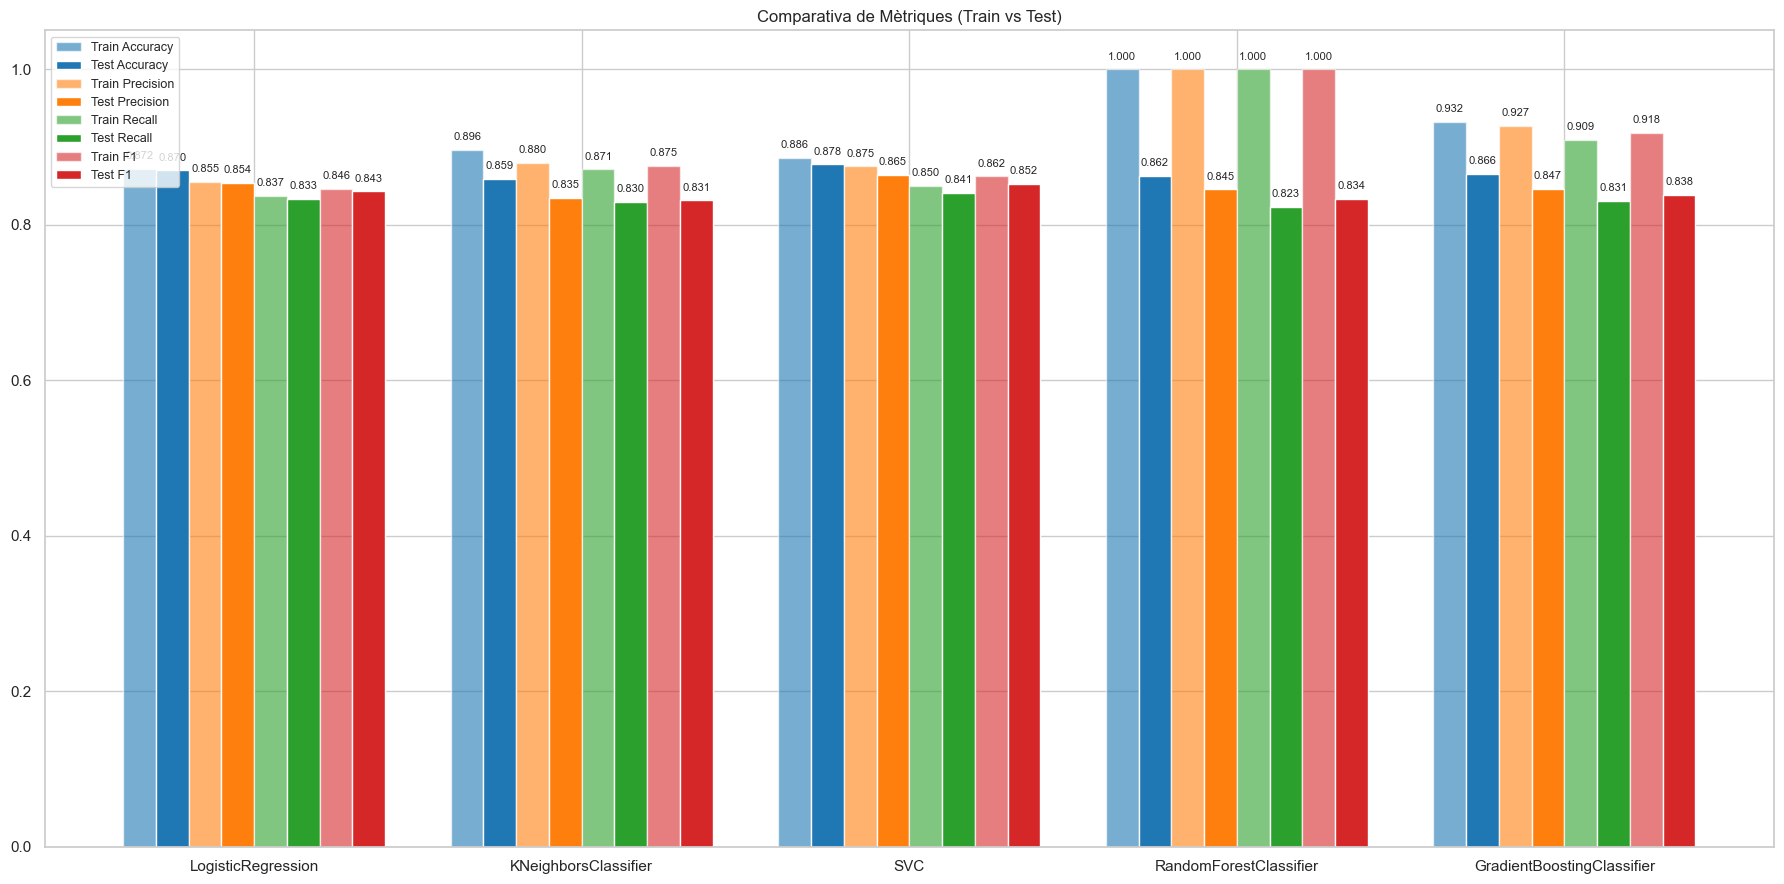

In [291]:
models_default = [model_class() for model_class in MODELS.values()]
print(models_default)
visualizer = ModelPerformanceVisualizer(models=models_default, dataframe=df_net, target='Class')
visualizer.run_evaluation()
visualizer.display_metrics()

In [292]:
# Crear DataFrame amb totes les mètriques
metrics_df = pd.DataFrame(visualizer.metrics)

# Afegim els noms dels models com a índex
metrics_df.index = MODELS.keys()

# Mostrar el DataFrame
pd.set_option('display.max_colwidth', None)
display(metrics_df)

,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1
Regressió Logística,0.872235,0.870013,0.854800,0.853637,0.837384,0.833333,0.845994,0.843072
KNN,0.896149,0.859140,0.879782,0.834972,0.871296,0.829630,0.875472,0.831323
SVM,0.886302,0.877768,0.875126,0.864581,0.850000,0.840741,0.862373,0.852156
Random Forest,0.999951,0.862446,0.999884,0.845467,1.000000,0.823148,0.999942,0.833644
Gradient Boosting,0.932043,0.865547,0.927198,0.846662,0.909259,0.830556,0.918122,0.838078


[LogisticRegression(C=1000), KNeighborsClassifier(metric='euclidean', n_neighbors=15, weights='distance'), SVC(C=1, gamma='auto'), RandomForestClassifier(criterion='entropy', min_samples_leaf=4, n_estimators=50), GradientBoostingClassifier(n_estimators=90)]


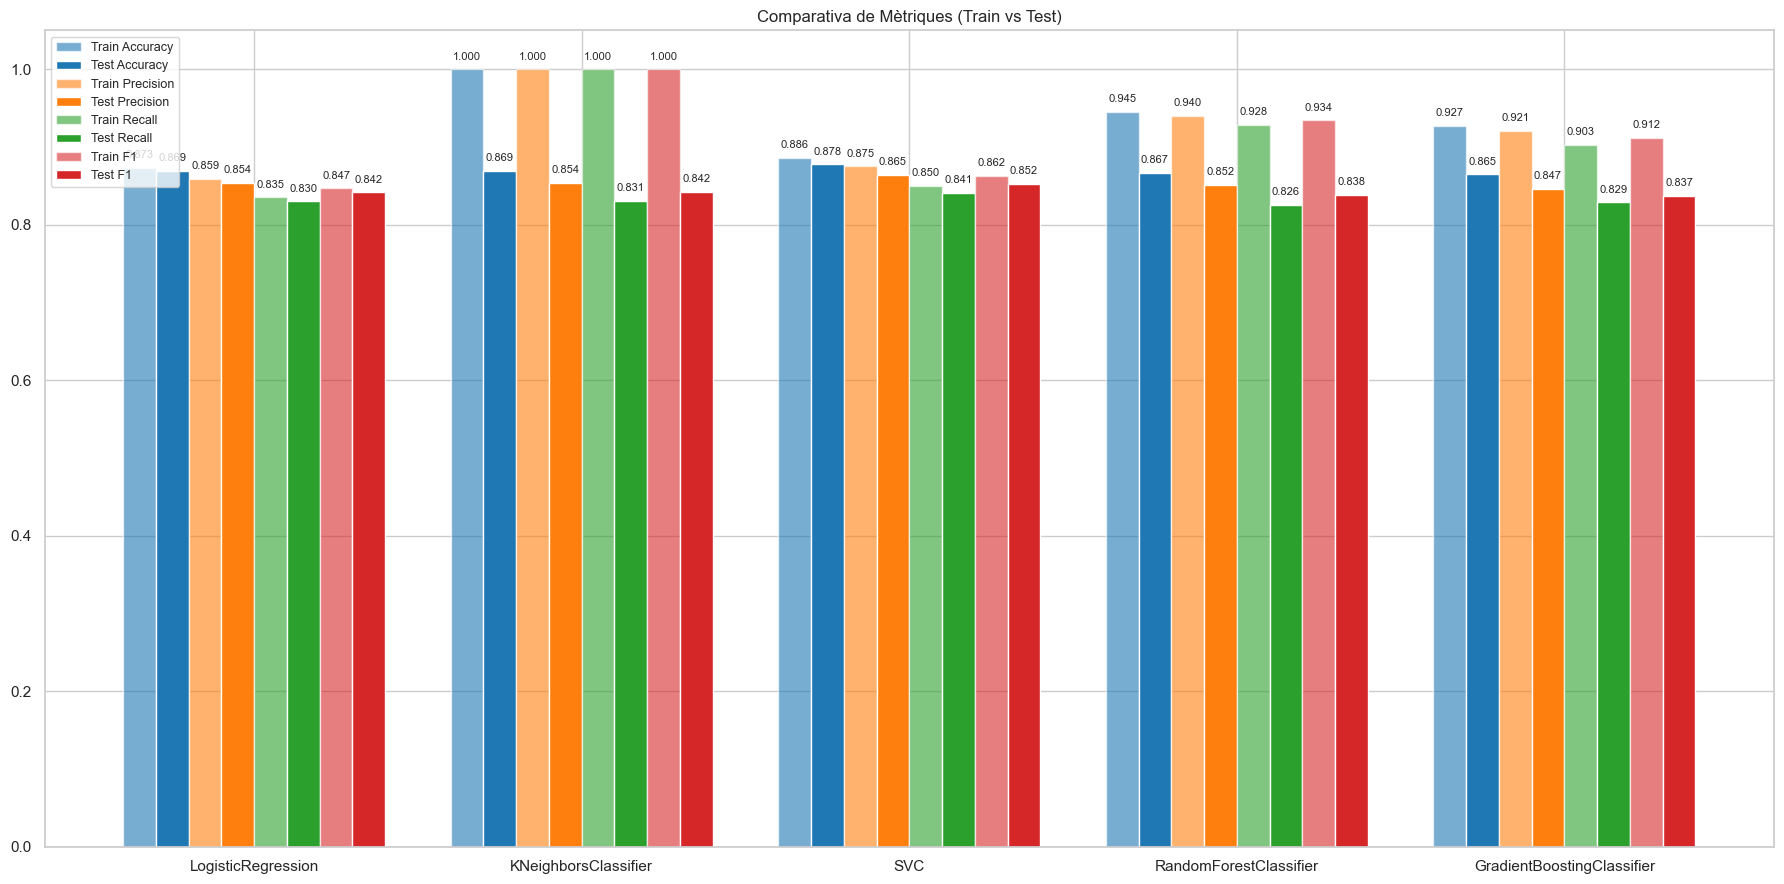

In [293]:
models_best_params = [model.model_class for model in opt_models.values() if hasattr(model, "model_class")]
print(models_best_params)

visualizer = ModelPerformanceVisualizer(models=models_best_params, dataframe=df_net, target='Class')
visualizer.run_evaluation()
visualizer.display_metrics()

In [294]:
# Crear DataFrame amb totes les mètriques
metrics_df = pd.DataFrame(visualizer.metrics)

# Afegim els noms dels models com a índex
metrics_df.index = MODELS.keys()

# Mostrar el DataFrame
pd.set_option('display.max_colwidth', None)
display(metrics_df)

,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1
Regressió Logística,0.873400,0.869235,0.858852,0.854369,0.835185,0.830093,0.846844,0.841744
KNN,1.000000,0.869427,1.000000,0.854106,1.000000,0.831019,1.000000,0.841929
SVM,0.886351,0.877768,0.875230,0.864581,0.850000,0.840741,0.862424,0.852156
Random Forest,0.945236,0.866520,0.940462,0.851804,0.928125,0.825926,0.934233,0.838243
Gradient Boosting,0.926853,0.864965,0.920925,0.846644,0.903009,0.828704,0.911864,0.837196


In [295]:
results = []

cols = df_net.drop("Class", axis=1).columns.tolist()
n = 4

for model_name, model_class in MODELS.items():
    print(f"Processant model: {model_name}")

    # Itera totes les combinacions de 1 a n variables
    features_combinations = []
    for r in range(1, n):
        features_combinations.extend(combinations(cols, r))

    for features in tqdm(features_combinations, desc=f"Features - {model_name}", leave=False):
        # Retorna nou dataset amb només aquestes features + target
        df_subset = DatasetAnalyzer(df_net).update_dataset(features=list(features))

        # Creem un model nou amb aquest dataset
        model = Model(
            model_class=model_class,
            dataframe=df_subset,
            target="Class",
        )

        # Predir i avaluar
        model.predict()
        metrics = Metrics.evaluate(model)

        results.append({"Model": model_name, "Features": features, **metrics})



Processant model: Regressió Logística


Features - Regressió Logística:   1%|▏         | 3/231 [00:00<00:10, 22.73it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Features - Regressió Logística:   3%|▎         | 6/231 [00:00<00:09, 23.71it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_cla

Processant model: KNN


Processant model: SVM


Features - SVM:   1%|          | 2/231 [00:00<00:25,  9.08it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Features - SVM:   2%|▏         | 5/231 [00:00<00:22,  9.92it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Features - SVM:   3%|▎         | 8/231 [00:00<00:23,  9.33it/s]c:\Users\ricar\OneDrive\MATCAD\MATCAD-3r\Aprenentatge Computacional\.venv\Lib\sit

Processant model: Random Forest


Processant model: Gradient Boosting


In [296]:
results_df = pd.DataFrame(results)
results_df


,Model,Features,Accuracy,Precision,Recall,F1,AUC-ROC,AUC_PR
0,Regressió Logística,"(AREA,)",0.787791,0.793388,0.666667,0.724528,0.874757,0.859245
1,Regressió Logística,"(PERIMETER,)",0.598837,0.557692,0.201389,0.295918,0.567431,0.498732
2,Regressió Logística,"(MAJOR_AXIS,)",0.561047,0.422222,0.131944,0.201058,0.552674,0.459708
3,Regressió Logística,"(MINOR_AXIS,)",0.825581,0.838710,0.722222,0.776119,0.916597,0.887657
4,Regressió Logística,"(SOLIDITY,)",0.581395,0.000000,0.000000,0.000000,0.639687,0.612967
...,...,...,...,...,...,...,...,...
1150,Gradient Boosting,"(ASPECT_RATIO, SHAPEFACTOR_2, SHAPEFACTOR_3)",0.877907,0.859155,0.847222,0.853147,0.937031,0.933428
1151,Gradient Boosting,"(ROUNDNESS, SHAPEFACTOR_1, SHAPEFACTOR_2)",0.872093,0.862319,0.826389,0.843972,0.935642,0.921991
1152,Gradient Boosting,"(ROUNDNESS, SHAPEFACTOR_1, SHAPEFACTOR_3)",0.854651,0.845588,0.798611,0.821429,0.935382,0.922412
1153,Gradient Boosting,"(ROUNDNESS, SHAPEFACTOR_2, SHAPEFACTOR_3)",0.863372,0.843972,0.826389,0.835088,0.933542,0.921008
